# 🦟 Predicción de Casos de Dengue – Enfoque de Aprendizaje Supervisado

**Autor:** Javier Piay Rodríguez  




---
# Resumen

En esta práctica se aborda el problema de predicción de casos de dengue en las ciudades de San Juan e Iquitos mediante un enfoque completo de análisis de datos y modelado predictivo. Se inicia  con una fase de reexploración en la que se analizan de nuevo las distribuciones, tendencias temporales y correlaciones entre las variables climáticas, pero en este caso en relacion con la variable objetivo (`total_cases`). De esta forma se busca identificar patrones estacionales, así como diferencias notables entre ambas ciudades, para orientar mejor las decisiones de modelado.

Posteriormente, se lleva a cabo una limpieza profunda de los datos. Esto incluye la eliminación de filas con excesivos valores nulos, la imputación de los valores faltantes restantes mediante `IterativeImputer`, y la detección y eliminación de valores atípicos extremos utilizando el criterio de 3 * IQR. También se transforma la variable categórica city a una versión binarizada, y se realizan transformaciones temporales (como month_sin, week_cos, etc.) para capturar estacionalidades. Más adelante, se entrenan varios modelos de predicción, como Random Forest, SVR y KNN, evaluando su rendimiento mediante validación cruzada y métricas como MAE. En base a los resultados obtenidos, se profundiza más en la familia de modelos basados en árboles de decisión y métodos de ensamblado. A pesar de la idea inicial que se observa en la reexploración de crear un modelo para cada una de las ciudades se ha puesto el foco en crear un modelo único robusto.

En el área de predicción,  se exploran los modelos básicos de  Random Forest, Gradient Boosting, KNN, SVR y XGBoost, sin ajustes de hiperparámetros. Después, mediante `RandomizedSearch` `GridSearch`y `Optuna`se intentan optimizar al máximo aquellos algoritmos que mejores resultados han proporcionado, destacando XGBoost y KNN con valores muy cercanos a 25.6.

---
# Inicialización

In [ ]:
# Imports generales
import pandas as pd
import io
from google.colab import files
import numpy as np
import time

seed = 42  # Semilla aleatoria arbitraria y constante a incluir en los algoritmos estocásticos para que los experimentos sean siempre reproducibles por el profesor.
# OJO: En los experimentos estocásticos que requieran varias iteraciones con distintas semillas, podéis incorporarla como seed+1, seed+2, etc.

def upload_files (index_fields=None):
  uploaded = files.upload()
  for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), index_col = index_fields)

    return df

def download_predictions(test, pred_total_cases):
  file_name = "practica2_pred_" + time.strftime("%Y") + time.strftime("%m") + time.strftime("%d") + time.strftime("%H") + time.strftime("%M") + time.strftime("%S") + ".csv"
  predictions = pd.DataFrame({ 'city': test['city'], 'year': test['year'], 'weekofyear': test['weekofyear'], 'total_cases': pred_total_cases})
  with open(file_name, 'w') as f:
    predictions.to_csv(f, index = False)
  files.download(file_name)
  print("Downloaded " + file_name)

In [ ]:
# Subir el conjunto de entrenamiento sin variable objetivo (dengue_features_train.csv)
train_feat = upload_files()
print(train_feat.shape)
train_feat.head()

Saving dengue_features_train.csv to dengue_features_train.csv
User uploaded file "dengue_features_train.csv" with length 287139 bytes
(1456, 24)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [ ]:
# Subir la variable objetivo total_cases del conjunto de entrenamiento (dengue_labels_train.csv)
train_labels = upload_files()

# Unificar el conjunto de entrenamiento (características + variable objetivo)
train = pd.merge(train_feat,train_labels,on=['city', 'year', 'weekofyear'])
print(train.shape)
train.head()

Saving dengue_labels_train.csv to dengue_labels_train.csv
User uploaded file "dengue_labels_train.csv" with length 19582 bytes
(1456, 25)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


In [ ]:
# Subir el conjunto de test sin variable objetivo (dengue_features_test.csv)
test = upload_files()
print(test.shape)
test.head()

Saving dengue_features_test.csv to dengue_features_test.csv
User uploaded file "dengue_features_test.csv" with length 82465 bytes
(416, 24)


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,2008,18,2008-04-29,-0.0189,-0.018900,0.102729,0.091200,78.60,298.492857,...,25.37,78.781429,78.60,15.918571,3.128571,26.528571,7.057143,33.3,21.7,75.2
1,sj,2008,19,2008-05-06,-0.0180,-0.012400,0.082043,0.072314,12.56,298.475714,...,21.83,78.230000,12.56,15.791429,2.571429,26.071429,5.557143,30.0,22.2,34.3
2,sj,2008,20,2008-05-13,-0.0015,NaN,0.151083,0.091529,3.66,299.455714,...,4.12,78.270000,3.66,16.674286,4.428571,27.928571,7.785714,32.8,22.8,3.0
3,sj,2008,21,2008-05-20,NaN,-0.019867,0.124329,0.125686,0.00,299.690000,...,2.20,73.015714,0.00,15.775714,4.342857,28.057143,6.271429,33.3,24.4,0.3
4,sj,2008,22,2008-05-27,0.0568,0.039833,0.062267,0.075914,0.76,299.780000,...,4.36,74.084286,0.76,16.137143,3.542857,27.614286,7.085714,33.3,23.3,84.1


Se genera una copia de los datos de test porque es necesaria la original para subirl el archivo a la plataforma en el formato correcto.

In [ ]:
test_original = test.copy()

---
# Reexploración

Como ya se identificó en la Práctica 1, las variables **'reanalysis_sat_precip_amt_mm'** y **'precipitation_amt_mm'**, así como **'reanalysis_specific_humidity_g_per_kg'** y **'reanalysis_dew_point_temp_k'**, mostraban una **correlación perfecta** (1.00), indicando que eran esencialmente duplicadas. Para evitar redundancia y posibles problemas de colinealidad, **se eliminan 'reanalysis_sat_precip_amt_mm' y 'reanalysis_specific_humidity_g_per_kg'**, manteniendo las más representativas en cada caso.

In [ ]:
# Eliminar variables redundantes por correlación perfecta (1.0)
train.drop(["reanalysis_sat_precip_amt_mm", "reanalysis_specific_humidity_g_per_kg"], axis=1, inplace=True)
test.drop(["reanalysis_sat_precip_amt_mm", "reanalysis_specific_humidity_g_per_kg"], axis=1, inplace=True)

  Se van a elaborar modelos con el dataset en su conjunto y separado por ciudades ya que en la práctica 1 se observaron 2 clsuters bien diferenciados. Por este motivo, la reexploración también se va llevar a cabo con el data set separado.

In [ ]:
# Separar los datos por ciudad
train_sj = train[train['city'] == 'sj'].copy()  # San Juan
train_iq = train[train['city'] == 'iq'].copy()  # Iquitos

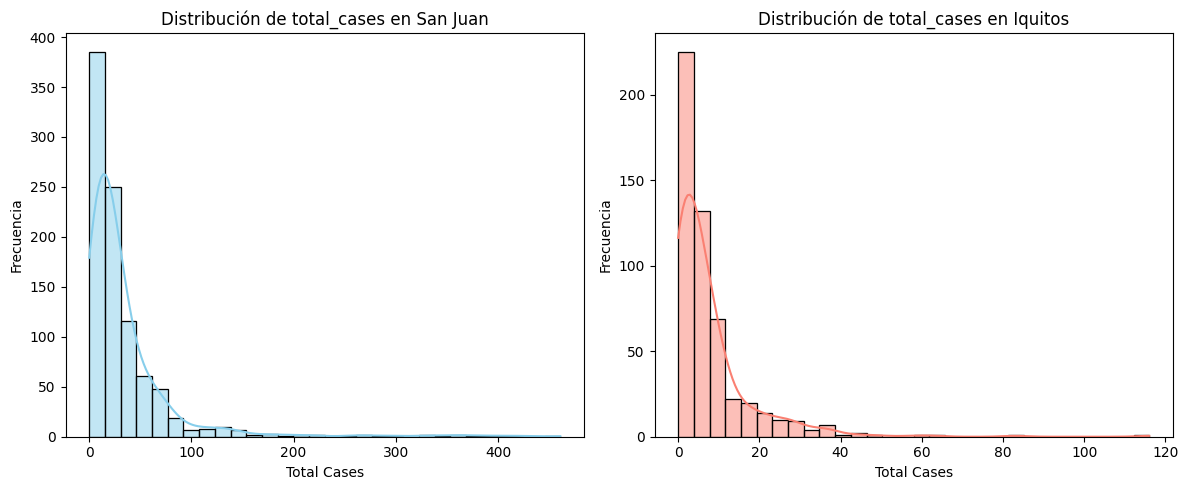

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de total_cases
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_sj['total_cases'], kde=True, bins=30, color='skyblue')
plt.title('Distribución de total_cases en San Juan')
plt.xlabel('Total Cases')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(train_iq['total_cases'], kde=True, bins=30, color='salmon')
plt.title('Distribución de total_cases en Iquitos')
plt.xlabel('Total Cases')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

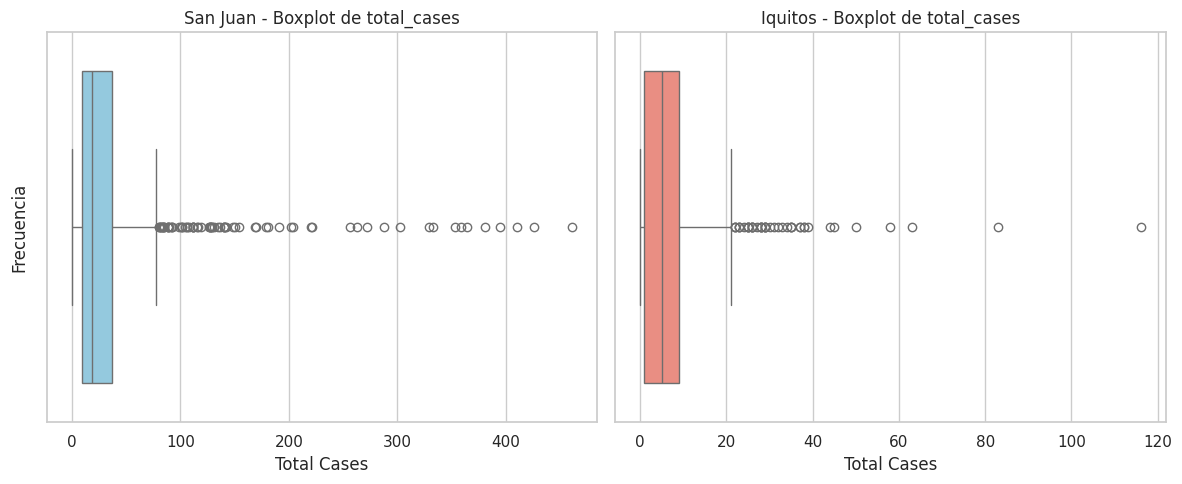

In [ ]:
# Estilo general
sns.set(style="whitegrid")

# Crear figura con subgráficos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

sns.boxplot(x=train_sj['total_cases'], color='skyblue')
plt.title('San Juan - Boxplot de total_cases')
plt.xlabel('Total Cases')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_iq['total_cases'], color='salmon')
plt.title('Iquitos - Boxplot de total_cases')
plt.xlabel('Total Cases')

plt.tight_layout()
plt.show()

In [ ]:
# Total de semanas con 0 casos en San Juan
zero_cases_sj = (train_sj['total_cases'] == 0).sum()
total_sj = len(train_sj)
print(f"San Juan - Semanas con 0 casos: {zero_cases_sj} ({(zero_cases_sj/total_sj)*100:.2f}%)")

# Total de semanas con 0 casos en Iquitos
zero_cases_iq = (train_iq['total_cases'] == 0).sum()
total_iq = len(train_iq)
print(f"Iquitos - Semanas con 0 casos: {zero_cases_iq} ({(zero_cases_iq/total_iq)*100:.2f}%)")


San Juan - Semanas con 0 casos: 4 (0.43%)
Iquitos - Semanas con 0 casos: 96 (18.46%)


In [ ]:
print("San Juan:\n", train_sj['total_cases'].describe())
print("\nIquitos:\n", train_iq['total_cases'].describe())


San Juan:
 count    936.000000
mean      34.180556
std       51.381372
min        0.000000
25%        9.000000
50%       19.000000
75%       37.000000
max      461.000000
Name: total_cases, dtype: float64

Iquitos:
 count    520.000000
mean       7.565385
std       10.765478
min        0.000000
25%        1.000000
50%        5.000000
75%        9.000000
max      116.000000
Name: total_cases, dtype: float64


Para explorar la distribución de la variable objetivo total_cases, se realizaron histogramas y boxplots por separado para San Juan e Iquitos.

* En **San Juan**, la mayoría de los casos se concentran por debajo de 50, aunque existen valores extremos que superan los 200 casos en una semana. El histograma muestra una distribución asimétrica a la derecha, lo cual indica que la mayoría de los valores son bajos, pero hay algunos brotes importantes. El boxplot confirma esta asimetría, mostrando una gran cantidad de outliers por encima del tercer cuartil.

* En **Iquitos**, la distribución también es asimétrica, aunque presenta una mayor proporción de semanas con 0 casos. Los valores extremos no alcanzan cifras tan altas como en San Juan, aunque también se observan outliers. El rango intercuartílico es más pequeño, lo cual sugiere una menor variabilidad.

Estas observaciones permiten sacar algunas conclusiones clave:

* La variable total_cases presenta una alta variabilidad y presencia de valores extremos en ambas ciudades, aunque más acentuada en San Juan.

* Dada la fuerte asimetría, podría considerarse aplicar transformaciones (por ejemplo, log(1 + x)) para normalizar los valores en algunos modelos.

* El comportamiento distinto entre ciudades refuerza la decisión de analizarlas por separado o, al menos, incluir la ciudad como variable categórica en modelos conjuntos.



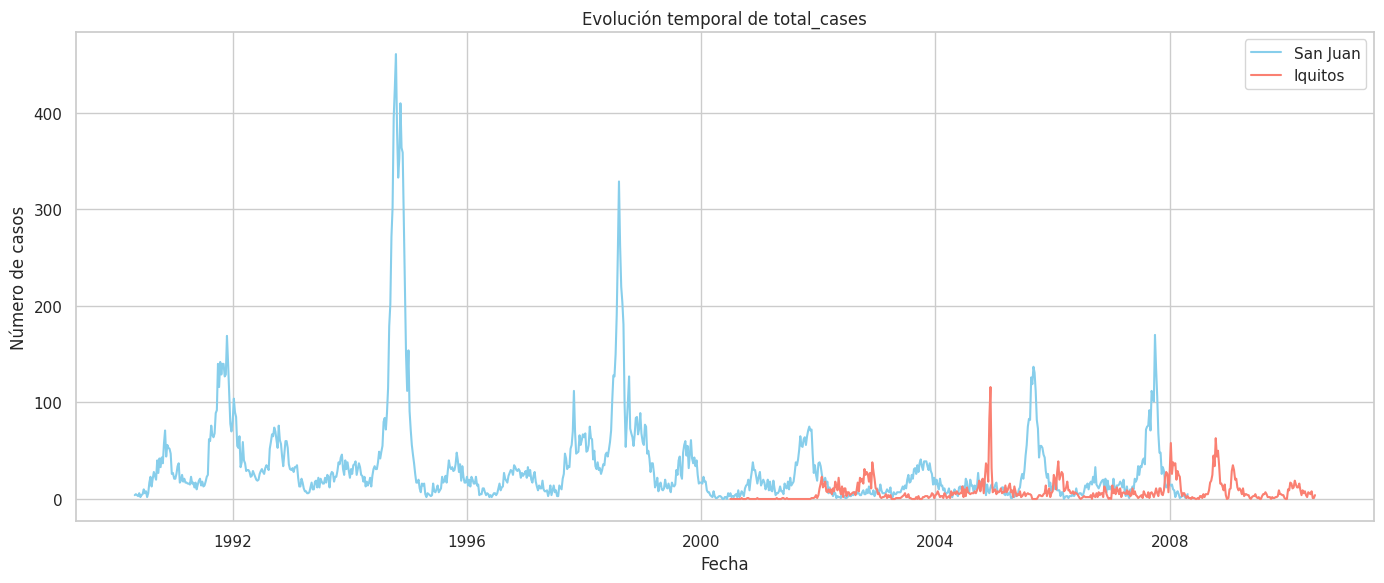

In [ ]:
import matplotlib.pyplot as plt

# Asegurarnos de que las fechas estén en formato datetime
train_sj['week_start_date'] = pd.to_datetime(train_sj['week_start_date'])
train_iq['week_start_date'] = pd.to_datetime(train_iq['week_start_date'])
test['week_start_date'] = pd.to_datetime(test['week_start_date'])

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(train_sj['week_start_date'], train_sj['total_cases'], label='San Juan', color='skyblue')
plt.plot(train_iq['week_start_date'], train_iq['total_cases'], label='Iquitos', color='salmon')

plt.title('Evolución temporal de total_cases')
plt.xlabel('Fecha')
plt.ylabel('Número de casos')
plt.legend()
plt.tight_layout()
plt.show()


Al observar la evolución temporal de los casos semanales:

* San Juan presenta brotes epidémicos muy marcados que aparecen de forma cíclica, aproximadamente cada 1-2 años, con picos que superan los 300 casos. Esta estacionalidad sugiere una fuerte influencia climática o ambiental.

* Iquitos tiene una evolución mucho más suave y con menos picos pronunciados. Aunque también hay aumentos puntuales, no superan los 120 casos por semana y su frecuencia es menos regular.

Esta diferencia refuerza la necesidad de tratar las ciudades como series temporales distintas. Además, podría ser útil extraer variables temporales como month, o incluso una codificación cíclica del mes o semana para alimentar los modelos de predicción. Esto es, variables como el mes o la semana son cíclicas. Es decir, diciembre (12) y enero (1) están muy cerca temporalmente, pero si lo codificas como enteros normales (1 a 12), el modelo cree que están muy lejos (1 vs. 12).


Con el objetivo de capturar patrones estacionales y temporales que puedan influir en la aparición de casos de dengue, se realizó una expansión del análisis temporal del dataset.

A pesar de que el conjunto de datos ya incluye las variables year y weekofyear, se decidió:

**1. Extraer el mes (month) desde la fecha de inicio de semana (week_start_date)**

Esto permite identificar patrones mensuales recurrentes (por ejemplo, picos estacionales durante los meses lluviosos). La variable month puede reflejar mejor ciertos comportamientos que la semana del año (weekofyear), especialmente en fenómenos relacionados con el clima o la vegetación.

In [ ]:
train_sj['month'] = train_sj['week_start_date'].dt.month
train_iq['month'] = train_iq['week_start_date'].dt.month
test['month'] = test['week_start_date'].dt.month

Aunque tengamos weekofyear, a veces el mes tiene más peso estacional (por lluvias, temperaturas, etc.).

**2. Codificar variables cíclicas (month y weekofyear)**

Tanto el mes como la semana del año tienen naturaleza cíclica (el mes 12 está junto al 1, la semana 52 junto a la 1). Para evitar que el modelo interprete erróneamente que diciembre (12) está muy alejado de enero (1), se aplicó una codificación cíclica mediante funciones seno y coseno:

In [ ]:
# San Juan
train_sj['month_sin'] = np.sin(2 * np.pi * train_sj['month'] / 12)
train_sj['month_cos'] = np.cos(2 * np.pi * train_sj['month'] / 12)

# Iquitos
train_iq['month_sin'] = np.sin(2 * np.pi * train_iq['month'] / 12)
train_iq['month_cos'] = np.cos(2 * np.pi * train_iq['month'] / 12)

# test
test['month_sin'] = np.sin(2 * np.pi * test['month'] / 12)
test['month_cos'] = np.cos(2 * np.pi * test['month'] / 12)

In [ ]:
# Para San Juan
train_sj['week_sin'] = np.sin(2 * np.pi * train_sj['weekofyear'] / 52)
train_sj['week_cos'] = np.cos(2 * np.pi * train_sj['weekofyear'] / 52)

# Para Iquitos
train_iq['week_sin'] = np.sin(2 * np.pi * train_iq['weekofyear'] / 52)
train_iq['week_cos'] = np.cos(2 * np.pi * train_iq['weekofyear'] / 52)

# Para test
test['week_sin'] = np.sin(2 * np.pi * test['weekofyear'] / 52)
test['week_cos'] = np.cos(2 * np.pi * test['weekofyear'] / 52)


Esta codificación cíclica permite que los modelos entiendan mejor las relaciones temporales, evitando saltos artificiales entre los valores 1 y 12 (o 1 y 52), lo cual es especialmente importante en modelos como KNN, redes neuronales o incluso árboles, que no modelan explícitamente esa circularidad.


In [ ]:
test.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,month,month_sin,month_cos,week_sin,week_cos
0,sj,2008,18,2008-04-29,-0.0189,-0.018900,0.102729,0.091200,78.60,298.492857,...,26.528571,7.057143,33.3,21.7,75.2,4,0.866025,-0.500000,0.822984,-0.568065
1,sj,2008,19,2008-05-06,-0.0180,-0.012400,0.082043,0.072314,12.56,298.475714,...,26.071429,5.557143,30.0,22.2,34.3,5,0.500000,-0.866025,0.748511,-0.663123
2,sj,2008,20,2008-05-13,-0.0015,NaN,0.151083,0.091529,3.66,299.455714,...,27.928571,7.785714,32.8,22.8,3.0,5,0.500000,-0.866025,0.663123,-0.748511
3,sj,2008,21,2008-05-20,NaN,-0.019867,0.124329,0.125686,0.00,299.690000,...,28.057143,6.271429,33.3,24.4,0.3,5,0.500000,-0.866025,0.568065,-0.822984
4,sj,2008,22,2008-05-27,0.0568,0.039833,0.062267,0.075914,0.76,299.780000,...,27.614286,7.085714,33.3,23.3,84.1,5,0.500000,-0.866025,0.464723,-0.885456


Con el objetivo de identificar relaciones significativas entre las variables climáticas y la variable objetivo total_cases, se realiza el siguiente análisis bivariante.

Se han escogido las siguientes variables por 2 motivos:

* Su relación esperada con el dengue
* En la exploración previa de la práctica 1 estas variables ya mostraron comportamientos interesantes. Algunas aparecían como outliers, o se destacaban en PCA o clustering.

Variables:

* precipitation_amt_mm:
	* Más lluvia → más agua estancada → más criaderos → más mosquitos.

* reanalysis_relative_humidity_percent:
	* Alta humedad favorece la supervivencia del mosquito.

* reanalysis_dew_point_temp_k
 * Relacionada con la humedad absoluta, que también afecta al desarrollo.

* reanalysis_air_temp_k:
	* La temperatura influye directamente en la velocidad del ciclo del mosquito.


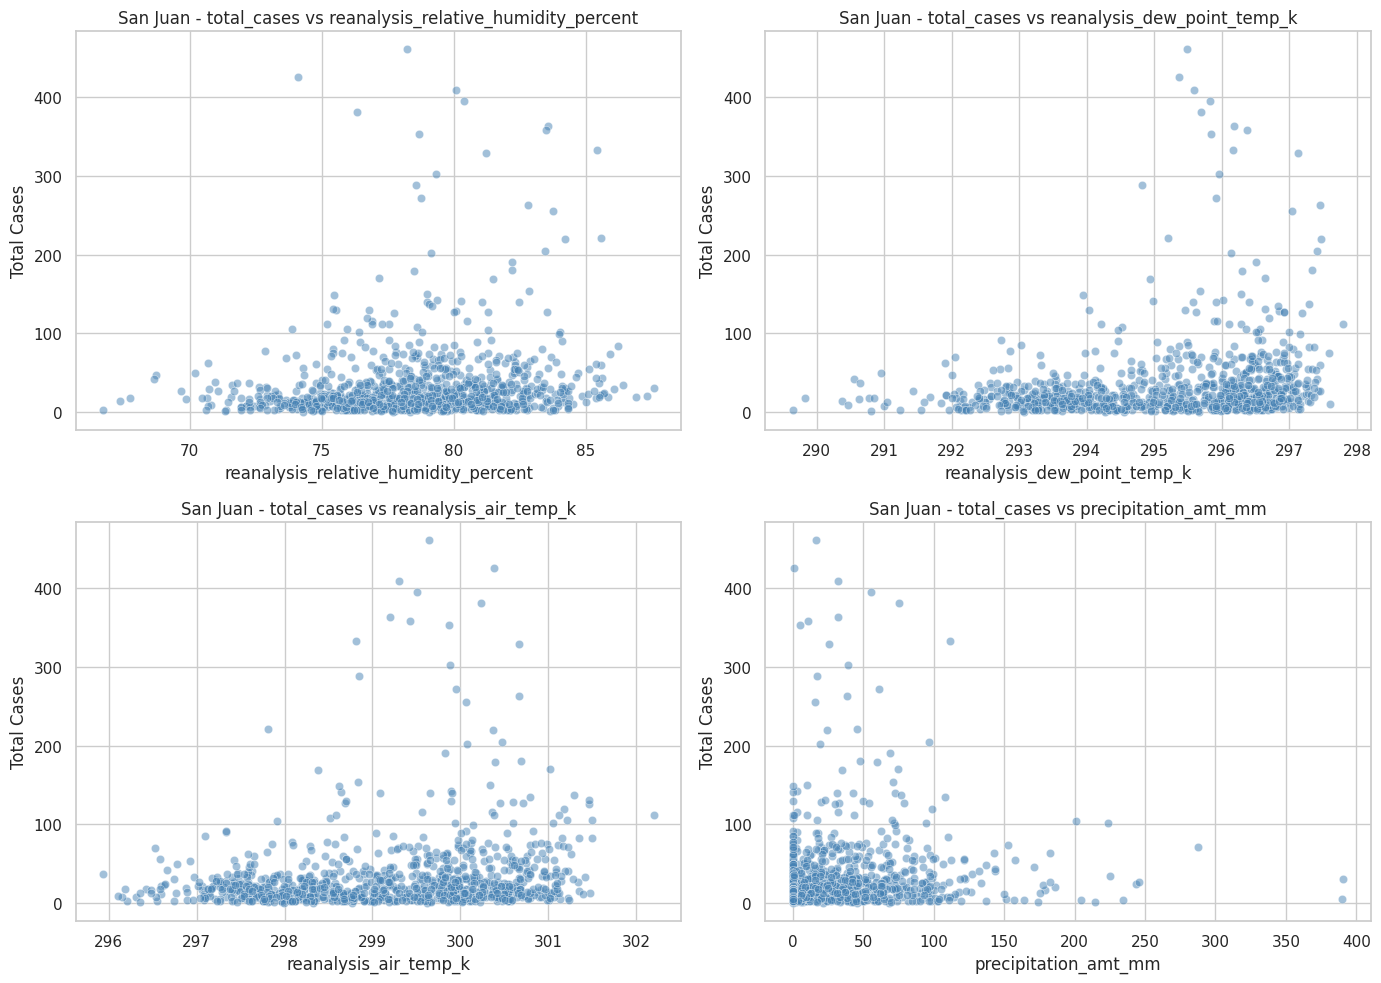

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features_sj = ['reanalysis_relative_humidity_percent', 'reanalysis_dew_point_temp_k',
               'reanalysis_air_temp_k', 'precipitation_amt_mm']

plt.figure(figsize=(14, 10))
for i, feature in enumerate(features_sj):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=train_sj, x=feature, y='total_cases', alpha=0.5, color='steelblue')
    plt.title(f'San Juan - total_cases vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Total Cases')
plt.tight_layout()
plt.show()


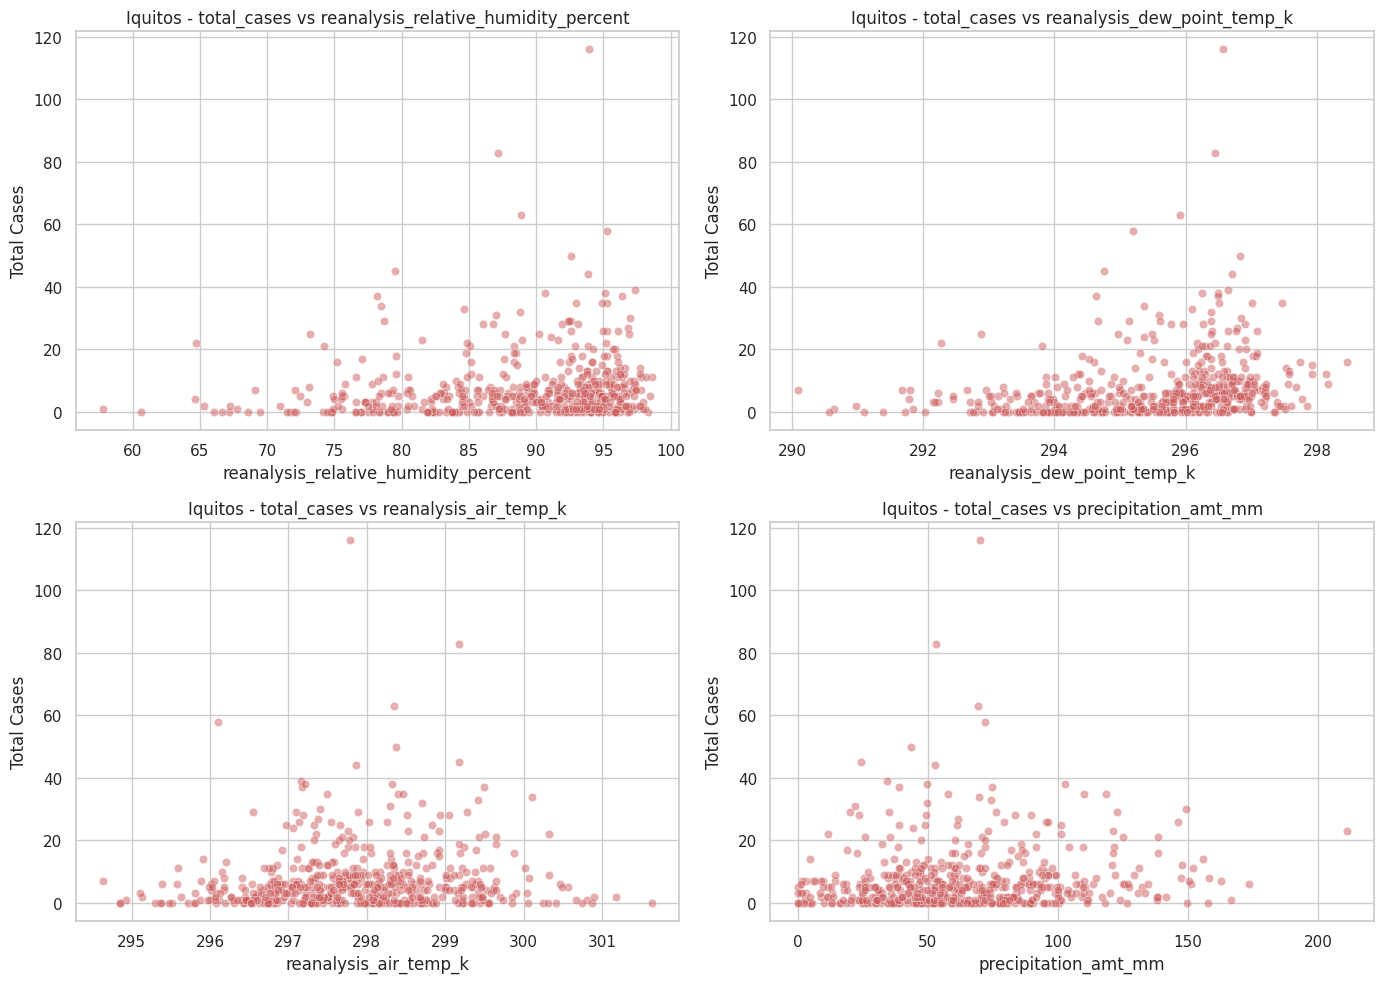

In [ ]:
features_iq = ['reanalysis_relative_humidity_percent', 'reanalysis_dew_point_temp_k',
               'reanalysis_air_temp_k', 'precipitation_amt_mm']

plt.figure(figsize=(14, 10))
for i, feature in enumerate(features_iq):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=train_iq, x=feature, y='total_cases', alpha=0.5, color='indianred')
    plt.title(f'Iquitos - total_cases vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Total Cases')
plt.tight_layout()
plt.show()


* En San Juan, se aprecian ligeras tendencias entre total_cases y variables como reanalysis_air_temp_k y precipitation_amt_mm, aunque con bastante dispersión. Esto sugiere que el clima podría influir, pero no de forma lineal directa.

* En Iquitos, la relación parece más plana, aunque se nota cierta aglomeración de valores bajos en condiciones específicas de humedad relativa.

En ambos casos, podría existir una relación no lineal, que se analizará más adelante.

In [ ]:
train_sj.dtypes

,0
city,object
year,int64
weekofyear,int64
week_start_date,datetime64[ns]
ndvi_ne,float64
ndvi_nw,float64
ndvi_se,float64
ndvi_sw,float64
precipitation_amt_mm,float64
reanalysis_air_temp_k,float64


Se calcula el coeficiente de correlación de Pearson entre la variable objetivo total_cases y el resto de variables numéricas.



<ipython-input-20-289477db8ef3>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='viridis')


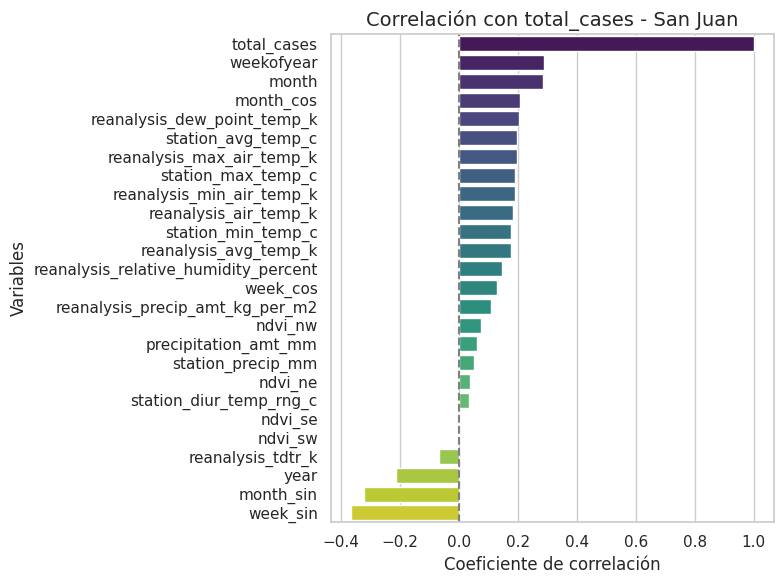

<ipython-input-20-289477db8ef3>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='viridis')


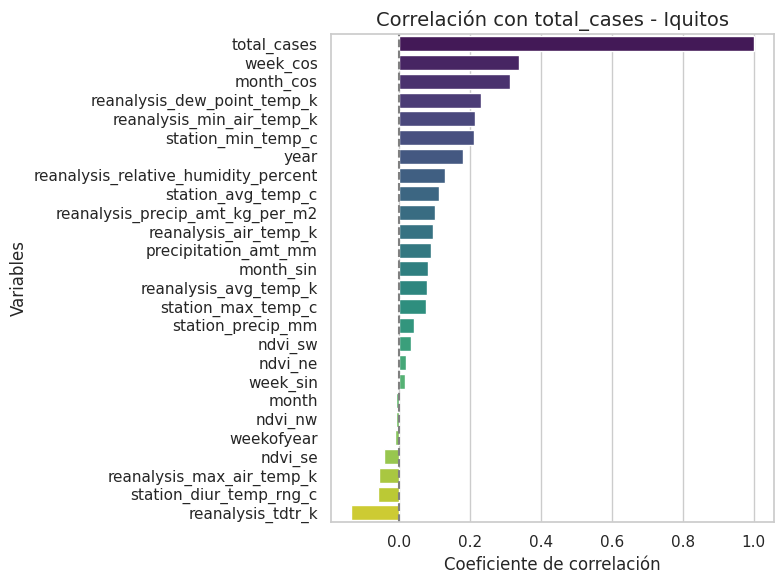

In [ ]:
def plot_target_corr(data, city_name):
    corr = data.corr(numeric_only=True)['total_cases'].sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=corr.values, y=corr.index, palette='viridis')
    plt.title(f'Correlación con total_cases - {city_name}', fontsize=14)
    plt.xlabel('Coeficiente de correlación')
    plt.ylabel('Variables')
    plt.axvline(0, color='gray', linestyle='--')
    plt.tight_layout()
    plt.show()

# Usar la función
plot_target_corr(train_sj, "San Juan")
plot_target_corr(train_iq, "Iquitos")


Ninguna variable parece estar altamente correlacionada con la variable objetivo, ya que los valores no alcanzan ni los 0.4. En general, ambas distribuciones son similiares. San Juan parece estar un poco más influenciado por patrones temporales (estacionalidad clara), es decir, por las variables relativas al tiempo, mientras que en Iquitos los factores climáticos como `reanalysis_dew_point_temp_k` dominan más.



Ahora **se eliminan las variables 'month', 'weekofyear' y 'week_start_date'** por su redundancia con las versiones codificadas de forma cíclica ('month_sin', 'month_cos', 'week_sin', 'week_cos'), las cuales capturan mejor la naturaleza periódica de estos atributos temporales. La variable 'year' se conserva al poder reflejar tendencias anuales no cíclicas, como brotes particulares en ciertos años.

In [ ]:
# EJEMPLO: Eliminar variables
train_sj.drop(['weekofyear', 'week_start_date', 'month'], axis = 1, inplace = True)
train_iq.drop(['weekofyear', 'week_start_date', 'month'], axis = 1, inplace = True)
test.drop(['weekofyear', 'week_start_date', 'month'], axis = 1, inplace = True)

In [ ]:
train_sj.dtypes

,0
city,object
year,int64
ndvi_ne,float64
ndvi_nw,float64
ndvi_se,float64
ndvi_sw,float64
precipitation_amt_mm,float64
reanalysis_air_temp_k,float64
reanalysis_avg_temp_k,float64
reanalysis_dew_point_temp_k,float64


### Nulos y outliers

In [ ]:
nul_sj = train_sj.isnull().sum().sum()
nul_iq = train_iq.isnull().sum().sum()
nul_test = test.isnull().sum().sum()

print(f"Valores nulos en San Juan: {nul_sj}")
print(f"Valores nulos en Iquitos: {nul_iq}")
print(f"Valores nulos en test: {nul_test}")

Valores nulos en San Juan: 365
Valores nulos en Iquitos: 160
Valores nulos en test: 115


In [ ]:
# Filtrar las filas con más de 4 nulos fuera de la función
train_sj = train_sj[train_sj.isnull().sum(axis=1) <= 4].copy()
train_iq = train_iq[train_iq.isnull().sum(axis=1) <= 4].copy()


A continuación, se identifican y eliminan aquellas filas que presentan una cantidad elevada de valores nulos (más de 4 por fila), ya que la recuperación de tantos datos faltantes podría generar ruido o imputaciones poco fiables. Esta limpieza se aplica tanto a los conjuntos de entrenamiento (San Juan e Iquitos).

In [ ]:
nul_sj = train_sj.isnull().sum().sum()
nul_iq = train_iq.isnull().sum().sum()
nul_test = test.isnull().sum().sum()

print(f"Valores nulos en San Juan: {nul_sj}")
print(f"Valores nulos en Iquitos: {nul_iq}")
print(f"Valores nulos en test: {nul_test}")

Valores nulos en San Juan: 269
Valores nulos en Iquitos: 96
Valores nulos en test: 115


Se procede a eliminar **valores atípicos extremos**, utilizando el criterio clásico de IQR (valores por fuera de 3 * IQR). Para esto se excluyen variables como `city`, `year`, `total_cases` y las codificaciones temporales (`month_sin`, `month_cos`, etc.) que no tienen sentido analizar con esta lógica. Este paso busca eliminar posibles errores de medición o registros anómalos que puedan distorsionar el modelo.

In [ ]:
def eliminar_atipicos_y_extremos_excluyendo(df, columnas_excluir):
    # Filtramos las columnas que no están en la lista de exclusión
    columnas_a_analizar = [col for col in df.columns if col not in columnas_excluir]

    # Creamos una copia del DataFrame original para no modificarlo directamente
    df_limpio = df.copy()

    # Inicializamos un contador para el total de valores atípicos extremos
    total_atipicos_extremos = 0

    # Iteramos sobre las columnas que vamos a analizar
    for columna in columnas_a_analizar:
        # Calculamos los cuartiles y el IQR
        Q1 = round(df_limpio[columna].quantile(0.25),3)
        Q3 = round(df_limpio[columna].quantile(0.75),3)
        IQR = round(Q3 - Q1,3)

        # Límites para valores extremos (más allá de 3 * IQR)
        extremo_inferior = round(Q1 - 3 * IQR, 2)
        extremo_superior = round(Q3 + 3 * IQR, 2)

        # Identificamos los valores atípicos extremos (fuera de los límites 3 * IQR)
        valores_atipicos_extremos = df_limpio[(df_limpio[columna] < extremo_inferior) | (df_limpio[columna] > extremo_superior)]

        # Actualizamos el total de valores atípicos extremos encontrados
        total_atipicos_extremos += len(valores_atipicos_extremos)

        # Eliminamos los valores atípicos extremos
        df_limpio = df_limpio[~df_limpio[columna].isin(valores_atipicos_extremos[columna])]

    # Imprimimos el total de valores atípicos extremos encontrados
    print(f"\nTotal de valores atípicos extremos encontrados: {total_atipicos_extremos}")

    # Devolvemos el DataFrame limpio, sin los valores atípicos extremos
    return df_limpio

In [ ]:
columnas_a_excluir = ['city', 'year', 'total_cases', 'month_sin', 'month_cos','week_sin', 'week_cos']
train_iq = eliminar_atipicos_y_extremos_excluyendo(train_iq, columnas_a_excluir)


Total de valores atípicos extremos encontrados: 15


Una vez limpiados los datos, se aborda la imputación de los valores faltantes restantes con `IterativeImputer` como en la práctica 1, un imputador multivariable que predice valores faltantes en una columna utilizando las demás como input, de manera iterativa.

Para garantizar coherencia en la imputación:
- Se **han concatenado** los datasets de San Juan e Iquitos antes de aplicar `fit`, de modo que el imputador aprenda patrones comunes del conjunto completo de entrenamiento.
- Luego se ha aplicado la transformación (con `transform`) sobre `train_combined` y sobre el conjunto de test.
- **No se ha utilizado información del test para entrenar el imputador**, lo cual evita cualquier fuga de información (*data leakage*).



In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

# Juntar ambos sets de entrenamiento
train_combined = pd.concat([train_sj, train_iq], axis=0)
# Se elimina 'total_cases' porque test no tiene esta columna
train_imputer = train_combined.drop('total_cases', axis=1)

# 1. Unir para identificar columnas con nulos en total
all_data = pd.concat([train_imputer, test], axis=0)
columns_with_nulls = all_data.columns[all_data.isnull().any()]

# 2. Crear el imputador
imputer = IterativeImputer(max_iter=10, random_state=42)

# 3. Fit SOLO en el train (sin data leakage)
imputer.fit(train_imputer[columns_with_nulls])

# 4. Transformar tanto train como test
train_combined[columns_with_nulls] = imputer.transform(train_imputer[columns_with_nulls])
test[columns_with_nulls] = imputer.transform(test[columns_with_nulls])

# 5. Comprobar que no quedan nulos
print("Nulos en train:", train_combined.isnull().sum().sum())
print("Nulos en test:", test.isnull().sum().sum())

Nulos en train: 0
Nulos en test: 0


In [ ]:
train_combined.head()

,city,year,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,...,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,month_sin,month_cos,week_sin,week_cos
0,sj,1990,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,...,25.442857,6.900000,29.4,20.0,16.0,4,0.866025,-0.500000,0.822984,-0.568065
1,sj,1990,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,...,26.714286,6.371429,31.7,22.2,8.6,5,0.500000,-0.866025,0.748511,-0.663123
2,sj,1990,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,...,26.714286,6.485714,32.2,22.8,41.4,4,0.500000,-0.866025,0.663123,-0.748511
3,sj,1990,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,...,27.471429,6.771429,33.3,23.3,4.0,3,0.500000,-0.866025,0.568065,-0.822984
4,sj,1990,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,...,28.942857,9.371429,35.0,23.9,5.8,6,0.500000,-0.866025,0.464723,-0.885456


In [ ]:
# Binarizador para la variable categórica city en el conjunto de entrenamiento y test
from sklearn import preprocessing
lb = preprocessing.LabelBinarizer()
train_combined['city_bin'] = lb.fit_transform(train_combined['city'])
test['city_bin'] = lb.transform(test['city'])

train_combined.head()
# sj = 1
# iq = 0

,city,year,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,...,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,month_sin,month_cos,week_sin,week_cos,city_bin
0,sj,1990,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,...,6.900000,29.4,20.0,16.0,4,0.866025,-0.500000,0.822984,-0.568065,1
1,sj,1990,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,...,6.371429,31.7,22.2,8.6,5,0.500000,-0.866025,0.748511,-0.663123,1
2,sj,1990,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,...,6.485714,32.2,22.8,41.4,4,0.500000,-0.866025,0.663123,-0.748511,1
3,sj,1990,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,...,6.771429,33.3,23.3,4.0,3,0.500000,-0.866025,0.568065,-0.822984,1
4,sj,1990,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,...,9.371429,35.0,23.9,5.8,6,0.500000,-0.866025,0.464723,-0.885456,1


Se elimina la avriable `city` ahora que ya ha sido binarizada.

In [ ]:
train = train_combined.drop('city', axis = 1)
test = test.drop('city', axis = 1)

In [ ]:
train.head()

,year,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,...,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,month_sin,month_cos,week_sin,week_cos,city_bin
0,1990,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,...,6.900000,29.4,20.0,16.0,4,0.866025,-0.500000,0.822984,-0.568065,1
1,1990,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,...,6.371429,31.7,22.2,8.6,5,0.500000,-0.866025,0.748511,-0.663123,1
2,1990,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,...,6.485714,32.2,22.8,41.4,4,0.500000,-0.866025,0.663123,-0.748511,1
3,1990,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,...,6.771429,33.3,23.3,4.0,3,0.500000,-0.866025,0.568065,-0.822984,1
4,1990,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,...,9.371429,35.0,23.9,5.8,6,0.500000,-0.866025,0.464723,-0.885456,1


---
# Predicción

Para cada uno de los algoritmos que se han probado el procedimiento ha sido el siguiente:

* En primer lugar se ha trabajado con el modelo básico para obtener un valor inicial y tener una idea general de como responde el modelo.

* Después, mediante `RandomizedSearch` se ha tratado de optimizar para lograr unos resultados mejores que en el modelo básico

* Finalmente, en el caso de haber encontrado una buena configuración se ha intentado ajustar todavía más empleando `GridSearch` u `Optuna`.

Para la parte de postprocesado se convierten las predicciones en números enteros y se evita que la variable objetivo pueda tomar valores negativos.

### RandomForest - básico

Se va a empezar con un modelo básico de RandomForest para ver el resultado y a partir de ahí buscar optimizaciones y mejores métricas. En este algoritmo no es necesario normalizar. Los árboles no se ven afectados por la escala de las variables. Ellos dividen el espacio de decisiones basándose en umbrales de características.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import numpy as np

# Suponiendo que la variable objetivo es 'total_cases'
X = train.drop('total_cases', axis=1)
y = train['total_cases']

# División train-validación (para evaluación interna)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

En la celda anterior se separan las variables independientes (X) de la variable objetivo (y). Para tener una evaluación objetiva del modelo antes de hacer una submission, se genera un conjunto de validación con el 20 % de los datos de entrenamiento.



In [ ]:
# Random Forest básico (modelo: RandomForest-A)
model_rf_a = RandomForestRegressor(random_state=42)
model_rf_a.fit(X_train, y_train)

# Validación interna
y_valid_pred = model_rf_a.predict(X_valid)
mae_valid = np.mean(np.abs(y_valid - y_valid_pred))
print(f"MAE en validación (RandomForest-A): {mae_valid:.4f}")


MAE en validación (RandomForest-A): 15.1277


No parece un mal resultado por lo que se va a subir a la plataforma para ver la puntuación real y tener un valor inicial que sirva de referencia.

In [ ]:
# Ver los parámetros por defecto
print("Parámetros por defecto del modelo RandomForestRegressor:")
print(model_rf_a.get_params())

Parámetros por defecto del modelo RandomForestRegressor:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


Se imprimen los parámetros empleados ya que luego ayudarán en la optimización.

In [ ]:
# Predicción sobre el test
X_test = test.drop('total_cases', axis=1, errors='ignore')  # Por si acaso
y_test_pred = model_rf_a.predict(X_test)

# Postprocesado según las instrucciones
y_pred = np.rint(y_test_pred).astype(int)
y_pred[y_pred < 0] = 0


La celda superior se encarga de postprocesar los datos convirtiendo las predicciones en números enteros y evitando que la variable objetivo pueda tomar valores negativos, ya que no tendría sentido que el número total de casos fuese un valor negativo.

Para transformar los resultados en un archivo `.csv` se puede hacer de la siguiente forma o utilizar la funcion `'download_predictions'` que aparece en el documento.



In [ ]:
submission = test_original[['city', 'year', 'weekofyear']].copy()
submission['total_cases'] = y_pred  # Las predicciones ya postprocesadas

submission.to_csv("submission_rf_a.csv", index=False)


In [ ]:
from google.colab import files
files.download("submission_rf_a.csv")


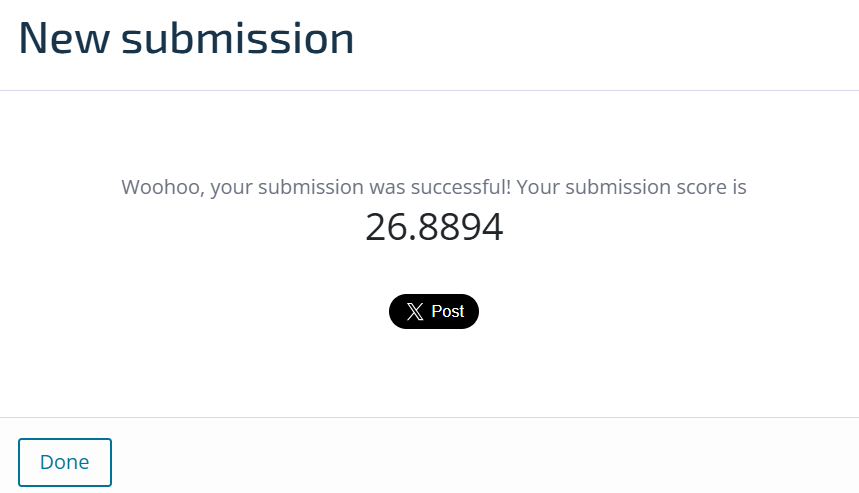


A partir de este valor de 26.8894 se va a optimizar el modelo para tratar de mejorarlo. Es necesario destacar que el MAE obtenido empleando nuestro conjunto de validación difiere en más de 10 puntos con el MAE real.

### RandomForest - Op


Se ha empleado el mismo espacio de hiperparámetros que ha escogido el profesor en la plantilla 1.- Optimización de hiperparámetros.

In [ ]:
from scipy.stats import randint as sp_randint
from sklearn.model_selection import RandomizedSearchCV

# Espacio de hiperparámetros
param_dist = {"n_estimators": [4, 8, 16, 32, 64, 128], # Number of trees in random forest
              "max_features": [1.0, 'sqrt'], # Number of features to consider at every split (1.0 is the old 'auto')
              "max_depth": [16, 12, 8, 4, 2,None], # Maximum number of levels in tree
              "min_samples_split": sp_randint(2, 50), #  Minimum number of samples required to split a node
              "min_samples_leaf": sp_randint(1, 50), # Minimum number of samples required at each leaf node
              "bootstrap": [True, False], # Method of selecting samples for training each tree
              "criterion": ["squared_error", "absolute_error"]}


In [ ]:
# Modelo base
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)

# Randomized Search con validación cruzada
random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=150,            # Número de combinaciones a probar
    cv=6,                 # Validación cruzada 6-fold
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1             # Usa todos los núcleos
)

# Ajustamos sobre el set de entrenamiento
random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=6, estimator=RandomForestRegressor(random_state=42),
                   n_iter=150, n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['squared_error',
                                                      'absolute_error'],
                                        'max_depth': [16, 12, 8, 4, 2, None],
                                        'max_features': [1.0, 'sqrt'],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7df3c8de0c90>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7df3cc4666d0>,
                                        'n_estimators': [4, 8, 16, 32, 64,
                                                         128]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [ ]:
# Mejor combinación encontrada
print("Mejores hiperparámetros (RandomForest-Opt):")
print(random_search.best_params_)

Mejores hiperparámetros (RandomForest-B):
{'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 16, 'max_features': 1.0, 'min_samples_leaf': 6, 'min_samples_split': 17, 'n_estimators': 64}


In [ ]:
# Predicción con el mejor modelo
best_rf_model = random_search.best_estimator_
y_valid_pred_b = best_rf_model.predict(X_valid)
mae_valid_b = np.mean(np.abs(y_valid - y_valid_pred_b))
print(f"MAE en validación (RandomForest-B): {mae_valid_b:.4f}")


MAE en validación (RandomForest-B): 13.9922


In [ ]:
# Predicción sobre el test
y_test_pred_b = best_rf_model.predict(X_test)

# Postprocesado: redondeo, enteros, cero mínimos
y_pred_b = np.rint(y_test_pred_b).astype(int)
y_pred_b[y_pred_b < 0] = 0


In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_pred_b)


La realidad es que se ha intentado optimizar el modelo varias veces y a pesar de que el MAE se ha visto reducido alrededor de 1 punto respecto al modelo básico, los resultados reales obtenidos han sido peores, con valores en torno a 26.9 y 27.1. Finalmente subir el número de iteraciones a 150 y emplear cross-validation con 6 particiones es lo que ha permitido obtener el valor que se registra a continuación.

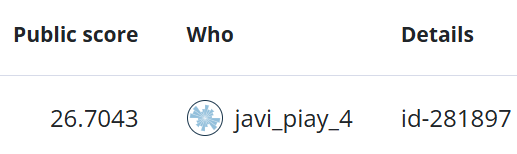

Ahora se va a aplicar Grid Search a ver si se consigue reducir todavía más el valor de 26.7043

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Afinamos la búsqueda alrededor de los mejores hiperparámetros encontrados
param_grid = {
    'n_estimators': [63, 64, 65],
    'max_depth': [14, 15, 16, 17,18],
    'min_samples_split': [15, 16, 17, 18, 19],
    'min_samples_leaf': [4, 5, 6, 7,8],
    'max_features': [1.0],
    'bootstrap': [True],
    'criterion': ['absolute_error']
}

# Modelo base
rf_model_grid = RandomForestRegressor(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model_grid,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

# Ajustar con el set de entrenamiento
grid_search.fit(X_train, y_train)

# Evaluación en validación
from sklearn.metrics import mean_absolute_error
y_valid_pred_grid = grid_search.predict(X_valid)
mae_grid = mean_absolute_error(y_valid, y_valid_pred_grid)
print(f"MAE en validación (GridSearch): {mae_grid:.4f}")



Fitting 5 folds for each of 375 candidates, totalling 1875 fits
MAE en validación (GridSearch): 14.1405


In [ ]:
# Elegimos el mejor modelo encontrado
best_rf_model_grid = grid_search.best_estimator_

In [ ]:
# Ahora sí: mostrar los mejores parámetros encontrados
print("Mejores hiperparámetros (GridSearch):")
print(grid_search.best_params_)

Mejores hiperparámetros (GridSearch):
{'bootstrap': True, 'criterion': 'absolute_error', 'max_depth': 14, 'max_features': 1.0, 'min_samples_leaf': 7, 'min_samples_split': 17, 'n_estimators': 63}


In [ ]:
# Predicción sobre el test
y_test_pred_c = best_rf_model_grid.predict(X_test)

# Postprocesado: redondeo, enteros, cero mínimos
y_pred_c = np.rint(y_test_pred_c).astype(int)
y_pred_c[y_pred_c < 0] = 0

In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_pred_c)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250419165123.csv


### RandomForest - manual


Se prueba un ajuste manual.

In [ ]:
model_manual= RandomForestRegressor(criterion='absolute_error', max_depth=15,
                      min_samples_leaf=6, min_samples_split=17, n_estimators=63,
                      random_state=42)
model_manual.fit(X_train, y_train)

y_valid_pred_d = model_manual.predict(X_valid)
mae_valid_b = np.mean(np.abs(y_valid - y_valid_pred_d))
print(f"MAE en validación (RandomForest-B): {mae_valid_b:.4f}")

MAE en validación (RandomForest-B): 13.9667


In [ ]:
# Predicción sobre el test
y_test_pred_d = model_manual.predict(X_test)

# Postprocesado: redondeo, enteros, cero mínimos
y_pred_d = np.rint(y_test_pred_d).astype(int)
y_pred_d[y_pred_d < 0] = 0

In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_pred_d)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250416225322.csv


Tras múltiples intentos no se ha conseguido con `GridSearch`obtener un valor mejor, tanto el MAE  en validación como el MAE real aumentaban ligeramente. No obstante, se ha decidido probar una serie de configuraciones manuales en base al modelo optimizado por `RandomizedSearch` con la suerte de encontrar una configuración que proporciona unos resultados ligeramente mejores.

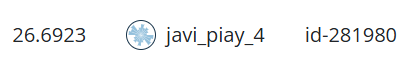

### SVR - básico

Ahora se busca probar un algoritmo completamente diferente para ver si se encuentran unos resultados mejores. En concreto, se va a utilizar SVR (Support Vector Regression), un modelo basado en los principios de las máquinas de soporte vectorial, que es especialmente útil para capturar relaciones no lineales entre las variables. Este enfoque permite controlar el margen de error permitido en las predicciones mediante el parámetro `epsilon`, así como regular la complejidad del modelo con el parámetro `C`. A diferencia de los modelos basados en árboles, como el Random Forest, SVR es sensible a la escala de las variables, por lo que será necesario normalizar o estandarizar los datos antes del entrenamiento para asegurar un buen rendimiento.

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

# Crear pipeline: escalado + SVR
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())  # Por defecto kernel='rbf'
])

# Entrenar el modelo
svm_pipeline.fit(X_train, y_train)

# Predecir sobre validación
y_val_pred_svm = svm_pipeline.predict(X_valid)

# Evaluar rendimiento
mae_svm = mean_absolute_error(y_valid, y_val_pred_svm)
print(f"MAE en validación con SVM: {mae_svm:.4f}")


MAE en validación con SVM: 16.2034


In [ ]:
print(svm_pipeline.named_steps['svr'].get_params())

{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [ ]:
# Predicción sobre el test
y_test_pred_svm = svm_pipeline.predict(test)

# Postprocesado: redondeo, enteros, cero mínimos
y_test_pred_svm = np.rint(y_test_pred_svm).astype(int)
y_test_pred_svm[y_test_pred_svm < 0] = 0

In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_test_pred_svm)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250421134234.csv


Como se refleja en la siguiente celda el modelo básico de SVR responde  mucho peor que el algoritmo RandomForest. Esto es esperable, ya que SVR es muy sensible a la escala de las variables y suele requerir una cuidadosa normalización de los datos, además de un ajuste fino de sus hiperparámetros (C, epsilon, gamma). Además, SVR no maneja tan bien la presencia de ruido, outliers ni la complejidad de interacciones entre variables como sí lo hacen los modelos de ensamble como Random Forest. Por estas razones, en problemas con datos tabulares y relaciones no lineales complejas (como este caso, que involucra múltiples variables climáticas y epidemiológicas), los modelos basados en árboles suelen ofrecer un mejor rendimiento y mayor robustez.

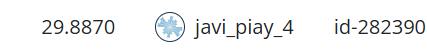

### SVR - Op

A pesar de partir de un modelo inicial peor, teniendo en cuenta que es un algoritmo muy sensible a los hiperparámetros se va a intentar ajustar.

Concretamente, se han utilizado los siguientes parámetros principales:

* `svr__C`: Controla la penalización por errores. Valores bajos permiten más tolerancia al error, mientras que valores altos hacen que el modelo se esfuerce más por minimizar los errores. Se busca entre 0.01 y 1000 usando una distribución logarítmica para cubrir distintos órdenes de magnitud.

* `svr__epsilon`: Define un margen de tolerancia alrededor de las predicciones en el que los errores no son penalizados. Afecta cuántos datos se consideran como errores reales. Se exploran valores entre 0 y 1.

* `svr__kernel`: Especifica la función núcleo (kernel) utilizada para transformar los datos al espacio de mayor dimensionalidad. Se prueban tres opciones:

  * `'rbf'` (función radial base, buena para relaciones no lineales),

  * `'linear'` (modelo lineal),

  * `'poly'` (kernel polinómico).

* `svr__degree`: Grado del polinomio cuando se utiliza el kernel 'poly'. Se exploran grados 2, 3 y 4. No afecta al modelo si se elige otro kernel.

* `svr__gamma`: Parámetro que define la influencia de cada punto de entrenamiento. 'scale' y 'auto' son configuraciones automáticas basadas en los datos. Solo se aplica cuando el kernel es 'rbf', 'poly' o 'sigmoid'.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, loguniform

# Pipeline para que escale dentro del CV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# Espacio de búsqueda
param_distributions = {
    'svr__C': loguniform(1e-2, 1e3),           # de 0.01 a 1000
    'svr__epsilon': uniform(0, 1),             # entre 0 y 1
    'svr__kernel': ['rbf', 'linear', 'poly'],  # tipos de kernel
    'svr__degree': [2, 3, 4],                  # solo se usa si kernel=poly
    'svr__gamma': ['scale', 'auto']
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=100,
    cv=6,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=6,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('svr', SVR())]),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'svr__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d4f46284550>,
                                        'svr__degree': [2, 3, 4],
                                        'svr__epsilon': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7d4f46f56cd0>,
                                        'svr__gamma': ['scale', 'auto'],
                                        'svr__kernel': ['rbf', 'linear',
                                                        'poly']},
                   random_state=42, scoring='neg_mean_absolute_error')

In [ ]:
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

print("MAE validación:")
from sklearn.metrics import mean_absolute_error
y_val_pred = random_search.predict(X_valid)
print(mean_absolute_error(y_valid, y_val_pred))


Mejores hiperparámetros encontrados:
{'svr__C': np.float64(22.12795469418204), 'svr__degree': 3, 'svr__epsilon': np.float64(0.009197051616629648), 'svr__gamma': 'auto', 'svr__kernel': 'rbf'}
MAE validación:
15.538746701265303


In [ ]:
# Predicción sobre el test
y_test_pred_svm_op = random_search.predict(test)

# Postprocesado: redondeo, enteros, cero mínimos
y_test_pred_svm_op = np.rint(y_test_pred_svm_op).astype(int)
y_test_pred_svm_op[y_test_pred_svm_op < 0] = 0

In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_test_pred_svm_op)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250424112735.csv


A pesar de reducir el MAE en nuestro conjunto de validación, la métrica real no ha logrado mejorar lo más mínimo por lo que SVR queda completamente descartado.

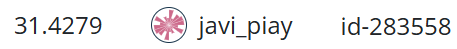

### KNN - básico

Como alternativa a los modelos utilizados, se va a probar K-Nearest Neighbors (KNN). Este algoritmo, basado en la idea de clasificar una observación según sus vecinos más cercanos, es simple y no paramétrico. Aunque generalmente no se considera el modelo más robusto para problemas con relaciones complejas o ruido, en este caso se utilizará para evaluar si su simplicidad puede generar buenos resultados y servir como una referencia comparativa frente a otros enfoques más sofisticados.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

# Crear pipeline: escalado + KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())  # Usará k=5 por defecto
])

# Entrenar modelo
knn_pipeline.fit(X_train, y_train)

# Predecir en validación
y_val_pred_KNN = knn_pipeline.predict(X_valid)

# Calcular MAE
from sklearn.metrics import mean_absolute_error
mae_knn = mean_absolute_error(y_valid, y_val_pred_KNN)
print(f"MAE en validación (KNN básico): {mae_knn:.4f}")


MAE en validación (KNN básico): 18.3192


In [ ]:
print(knn_pipeline.named_steps['knn'].get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [ ]:
# Predicción sobre el test
y_test_pred_knn = knn_pipeline.predict(test)

# Postprocesado: redondeo, enteros, cero mínimos
y_test_pred_knn = np.rint(y_test_pred_knn).astype(int)
y_test_pred_knn[y_test_pred_knn < 0] = 0

In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_test_pred_knn)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250421140050.csv


A pesar de que a priori cuenta con el MAE en validación más alto de los 3 modelos, se observa que ofrece mejores resultado que SVR. Quizás optimizándolo se lleguen a resultados similares a los de RandomForest.

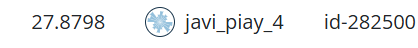

### KNN - Op

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint

# Definir pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Espacio de búsqueda
param_dist = {
    'knn__n_neighbors': randint(2, 100),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}


# Búsqueda aleatoria
random_search = RandomizedSearchCV(
    knn_pipeline,
    param_distributions=param_dist,
    n_iter=100,
    scoring='neg_mean_absolute_error',
    cv=6,
    random_state=40,
    verbose=1,
    n_jobs=-1
)

# Ajustar
random_search.fit(X_train, y_train)

# Mejor resultado
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

# MAE en validación
y_val_pred_knn_opt = random_search.predict(X_valid)
mae_knn_opt = mean_absolute_error(y_valid, y_val_pred_knn_opt)
print(f"MAE en validación (KNN optimizado): {mae_knn_opt:.4f}")


Fitting 6 folds for each of 100 candidates, totalling 600 fits
Mejores hiperparámetros encontrados:
{'knn__n_neighbors': 23, 'knn__p': 1, 'knn__weights': 'distance'}
MAE en validación (KNN optimizado): 16.3720


In [ ]:
print(random_search.best_estimator_.named_steps['knn'].get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 23, 'p': 1, 'weights': 'distance'}


In [ ]:
# Predecir en test con el mejor modelo
y_test_pred_knn_opt = random_search.predict(test)

# Postprocesar: redondear, convertir a enteros, y poner mínimo 0
y_test_pred_knn_opt = np.rint(y_test_pred_knn_opt).astype(int)
y_test_pred_knn_opt[y_test_pred_knn_opt < 0] = 0


In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_test_pred_knn_opt)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250425125444.csv


image.png

Meidante la optimización con `Randomized Search` se ha logrado reducir el MAE más de 2 puntos, obteniendo la mejor puntuación hasta el momento. Quizás mediante `GridSearch`se logra bajar de 25.6

### KNN- Grid

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# Definimos una rejilla
param_grid = {
    'knn__n_neighbors': [ 20, 23, 25, 27, 30],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2],
    'knn__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'knn__leaf_size': [20, 25, 30, 35],
    'knn__metric': ['minkowski', 'euclidean', 'manhattan']
}

# Grid Search
grid_search = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=6,
    verbose=1,
    n_jobs=-1
)

# Ajustar modelo
grid_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados (Grid Search):")
print(grid_search.best_params_)

# MAE en validación
y_val_pred_knn_grid = grid_search.predict(X_valid)
mae_knn_grid = mean_absolute_error(y_valid, y_val_pred_knn_grid)
print(f"MAE en validación (KNN Grid Search): {mae_knn_grid:.4f}")


Fitting 6 folds for each of 960 candidates, totalling 5760 fits
Mejores hiperparámetros encontrados (Grid Search):
{'knn__algorithm': 'auto', 'knn__leaf_size': 20, 'knn__metric': 'minkowski', 'knn__n_neighbors': 25, 'knn__p': 1, 'knn__weights': 'distance'}
MAE en validación (KNN Grid Search): 16.2737


In [ ]:
# Predecir en test con el mejor modelo de Grid Search
y_test_pred_knn_grid = grid_search.predict(test)

# Postprocesar: redondear, convertir a enteros, y poner mínimo 0
y_test_pred_knn_grid = np.rint(y_test_pred_knn_grid).astype(int)
y_test_pred_knn_grid[y_test_pred_knn_grid < 0] = 0

# Submission del modelo optimizado por Grid Search
download_predictions(test_original, y_test_pred_knn_grid)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250425130815.csv


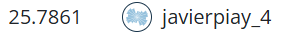

No se ha conseguido pasar del valor que refleja la imagen superior, aun así, la mejora ha sido suficiente para establecerse como mejor modelo. Teniendo en cuenta todos  los resultados obtenidos hasta el momento, como Random Forest Regressor también ha dado buenos resultados, parece adecuado explorar más a fondo la familia de modelos basados en árboles de decisión y métodos de ensamblado.

### Gradient Boosting - básico

A diferencia de Random Forest Regressor que entrena muchos árboles en paralelo sobre diferentes subconjuntos del dataset (bootstrapping) y luego hace una media de sus predicciones, Gradient Boosting Regressor entrena árboles en secuencia, donde cada árbol intenta corregir los errores del anterior (usando gradientes).

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Crear el modelo
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

# Predecir en validación
y_val_pred_gbr = gbr.predict(X_valid)
mae_gbr = mean_absolute_error(y_valid, y_val_pred_gbr)

print(f"MAE en validación (Gradient Boosting básico): {mae_gbr:.4f}")


MAE en validación (Gradient Boosting básico): 14.6336


In [ ]:
print(gbr.get_params())

{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


In [ ]:
# Predecir en test con el mejor modelo
y_test_pred_gbr = gbr.predict(test)

# Postprocesar: redondear, convertir a enteros, y poner mínimo 0
y_test_pred_gbr = np.rint(y_test_pred_gbr).astype(int)
y_test_pred_gbr[y_test_pred_gbr < 0] = 0

In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_test_pred_knn)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250421141535.csv


A pesar de obtener un MAE en validación relativamente bajo los resultados reales no son muy esperanzadores. Sin embargo, veamos si optimizando el modelo se logra una gran mejora.

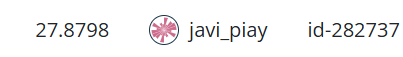

A la hora de optimizar los parámetros, la mayoría son los mismos que ya se han usado para Random Forest Regressor, pero se incluyen los siguientes:

* `learning_rate`: Controla cuánto contribuye cada nuevo árbol al modelo final. Valores más bajos suelen necesitar más árboles (n_estimators) pero pueden mejorar la generalización.

* `subsample`:	Proporción de datos usada para entrenar cada árbol. Si es menor que 1.0, introduce aleatoriedad y puede reducir el overfitting.


### Gradient Boosting-Op

Se optimiza el modelo usando `RandomizedSearch`.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform

# Modelo base
gbr = GradientBoostingRegressor(random_state=42)

# Espacio de hiperparámetros
param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 10),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'subsample': uniform(0.5, 0.5),

}

# RandomizedSearchCV
random_search_gbr = RandomizedSearchCV(
    gbr, param_distributions=param_dist,
    n_iter=75, cv=6, scoring='neg_mean_absolute_error',
    random_state=42, n_jobs=-1, verbose=1
)

# Entrenar búsqueda
random_search_gbr.fit(X_train, y_train)

# Evaluar mejor modelo
best_gbr = random_search_gbr.best_estimator_
y_val_pred_best_gbr = best_gbr.predict(X_valid)
mae_best_gbr = mean_absolute_error(y_valid, y_val_pred_best_gbr)

print(f"Mejor MAE en validación (GB optimizado): {mae_best_gbr:.4f}")
print("Mejores hiperparámetros:", random_search_gbr.best_params_)


Fitting 6 folds for each of 75 candidates, totalling 450 fits
Mejor MAE en validación (GB optimizado): 11.2558
Mejores hiperparámetros: {'learning_rate': np.float64(0.031098851966054122), 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 239, 'subsample': np.float64(0.7696711209578253)}


Se ha tratado de incluir también el párametro  `loss`, que define la función de pérdida que el modelo intenta minimizar. Pudiendo ser:

  * `'squared_error'`: penaliza más los errores grandes (por defecto).

  * `'absolute_error'`: más robusto frente a outliers.

  * `'huber'`: combina ambos.

Sin embargo, aunque al incluir este parámetro se logró reducir el MAE en validación hasta valores cercanos a 10.5, el MAE real en el conjunto de test no bajaba de 27. Esto sugiere la presencia de overfitting durante la validación.

In [ ]:
# Predecir en el conjunto de test
y_test_pred_gbr_rs = random_search_gbr.predict(test)

# Postprocesado: redondear, enteros, y eliminar negativos
y_test_pred_gbr_rs = np.rint(y_test_pred_gbr_rs).astype(int)
y_test_pred_gbr_rs[y_test_pred_gbr_rs < 0] = 0

In [ ]:
# Submission del modelo optimizado
download_predictions(test_original, y_test_pred_gbr_rs)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250421160119.csv


Tras una mejora significativa de más de 3 puntos en el MAE de validación empleando `RandomizedSearch`, se ha conseguido uan de las mejores puntuaciónes hasta el momento. Esto deja claro que la familia de árboles de decisión es bastante adecuada para este caso.

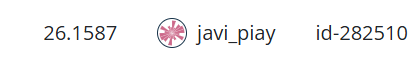

### Gradient Boosting-Optuna

Al utilizar `GridSearch` con hiperparámetros continuos, se encuentra una gran limitación: este método exige definir un conjunto discreto de valores, lo que reduce significativamente la capacidad de exploración del espacio de búsqueda. Esta rigidez no solo puede hacer que se pasen por alto combinaciones prometedoras, sino que también aumenta innecesariamente el coste computacional si se quiere cubrir un rango amplio.

Por esta razón, se decidió inicialmente utilizar `RandomizedSearchCV` y una vez identificadas combinaciones razonablemente buenas, emplear `Optuna` para refinar aún más la búsqueda.

Optuna es un framework de optimización bayesiana que utiliza técnicas como el Tree-structured Parzen Estimator (TPE) para guiar inteligentemente el proceso de búsqueda hacia regiones del espacio donde es más probable encontrar mejores resultados. A diferencia de `Randomized Search`, que es puramente aleatorio, Optuna aprende de las iteraciones anteriores para ajustar los parámetros en futuras pruebas, haciendo un uso mucho más eficiente de los recursos computacionales.


In [ ]:
 pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 17.8 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 180, 270),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0)
    }

    model = GradientBoostingRegressor(random_state=42, **params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)
    return mean_absolute_error(y_valid, y_pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f"Mejor MAE validación (Optuna): {study.best_value:.4f}")
print("Mejores hiperparámetros (Optuna):")
print(study.best_params)

# Modelo final con los mejores parámetros
best_gbr_optuna = GradientBoostingRegressor(random_state=42, **study.best_params)
best_gbr_optuna.fit(X_train, y_train)
y_val_optuna = best_gbr_optuna.predict(X_valid)
mae_optuna = mean_absolute_error(y_valid, y_val_optuna)
print(f"MAE final en validación (modelo Optuna): {mae_optuna:.4f}")


[I 2025-04-23 11:23:04,997] A new study created in memory with name: no-name-0c962e65-b8ad-435b-8231-1bdc8105d853


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-04-23 11:23:07,668] Trial 0 finished with value: 13.138560785099395 and parameters: {'n_estimators': 193, 'learning_rate': 0.014907615645911216, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 4, 'subsample': 0.5236926834862599}. Best is trial 0 with value: 13.138560785099395.
[I 2025-04-23 11:23:09,772] Trial 1 finished with value: 14.198918888349382 and parameters: {'n_estimators': 255, 'learning_rate': 0.12799740579576882, 'max_depth': 3, 'min_samples_split': 9, 'min_samples_leaf': 5, 'subsample': 0.8268097365860876}. Best is trial 0 with value: 13.138560785099395.
[I 2025-04-23 11:23:10,868] Trial 2 finished with value: 15.117525410326921 and parameters: {'n_estimators': 242, 'learning_rate': 0.02196048475869126, 'max_depth': 2, 'min_samples_split': 7, 'min_samples_leaf': 9, 'subsample': 0.6551615177244344}. Best is trial 0 with value: 13.138560785099395.
[I 2025-04-23 11:23:13,687] Trial 3 finished with value: 13.194965628102116 and parameters: {'n_estimators':

In [ ]:
y_test_pred_optuna = best_gbr_optuna.predict(test)

# Postprocesado
y_test_pred_optuna = np.rint(y_test_pred_optuna).astype(int)
y_test_pred_optuna[y_test_pred_optuna < 0] = 0

# Guardar las predicciones
download_predictions(test_original, y_test_pred_optuna)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250423113636.csv


Tras varios intentos buscando el ajuste óptimo lo único que se ha logrado es empeorar la puntuación seguramente por un problema de overfitting.

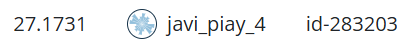

### XGBoost-básico

Tras obtener buenos resultados con modelos de árboles como `RandomForestRegressor` y `GradientBoostingRegressor`, es lógico explorar XGBoost como siguiente paso. XGBoost (`Extreme Gradient Boosting`) pertenece a la misma familia de métodos de ensamblado basados en árboles, pero se destaca por su eficiencia, regularización avanzada y capacidad para manejar datos complejos con mayor robustez.

En concreto, XGBoost suele superar a otros modelos de boosting tradicionales gracias a:

* Mejor manejo del overfitting mediante regularización (`reg_alpha`, `reg_lambda`).

* Entrenamiento más rápido y uso optimizado de memoria.

* Mayor control del modelo a través de hiperparámetros avanzados como `min_child_weight`, `colsample_bytree`, o `subsample`.

* Excelente rendimiento en competiciones de ciencia de datos, donde suele ser el modelo base de muchos ganadores.

Dado que Gradient Boosting ya ha mostrado resultados prometedores, probar XGBoost permite aprovechar su mayor capacidad de ajuste y eficiencia para intentar reducir aún más el error de predicción y mejorar el rendimiento general del modelo.

In [ ]:
# pip install xgboost

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Modelo base
xgb_base = XGBRegressor(random_state=42, verbosity=0)

# Entrenamos con los mismos datos
xgb_base.fit(X_train, y_train)

# Predicción en validación
y_val_pred_xgb = xgb_base.predict(X_valid)
mae_xgb = mean_absolute_error(y_valid, y_val_pred_xgb)

print(f"MAE en validación (XGB base): {mae_xgb:.4f}")


MAE en validación (XGB base): 11.6136


In [ ]:
print(xgb_base.get_params())

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': 0}


In [ ]:
# Predecir en el conjunto de test
y_test_pred_xgb_base = xgb_base.predict(test)

# Postprocesado: redondear, convertir a enteros y eliminar negativos
y_test_pred_xgb_base = np.rint(y_test_pred_xgb_base).astype(int)
y_test_pred_xgb_base[y_test_pred_xgb_base < 0] = 0


In [ ]:
download_predictions(test_original, y_test_pred_xgb_base)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250422105045.csv


Si se comprueba el MAE en validación se observa el valor más bajo con diferencia obtenido para un modelo básico. No obstante el MAE real no logra bajar de 27, pero teniendo en cuenta que al optimizar Gradient Boosting se mejoró enormemente el resultado se va a proceder a hacer lo mismo.

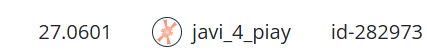

### XGBoost-Op

Algunos parámetros ya han sido empleados en otros modelos de la familia, los nuevos son:

* `min_child_weight`: Mínimo peso (suma de instancias) requerido en una hoja. Valores más altos hacen el modelo más conservador.

* `colsample_bytree`:	Fracción de características seleccionadas al azar para cada árbol. También aporta aleatoriedad y reduce la varianza.


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error
from scipy.stats import randint, uniform


xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5)
}


In [ ]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=75,
    cv=6,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_xgb.fit(X_train, y_train)

best_xgb = random_search_xgb.best_estimator_

y_val_pred_xgb = best_xgb.predict(X_valid)
mae_val_xgb = mean_absolute_error(y_valid, y_val_pred_xgb)

print(f"Mejor MAE en validación (XGBoost optimizado): {mae_val_xgb:.4f}")
print("Mejores hiperparámetros:", random_search_xgb.best_params_)


Fitting 6 folds for each of 75 candidates, totalling 450 fits
Mejor MAE en validación (XGBoost optimizado): 11.8215
Mejores hiperparámetros: {'colsample_bytree': np.float64(0.5943535541706897), 'learning_rate': np.float64(0.06577427051843637), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 197, 'subsample': np.float64(0.9435432121325587)}


In [ ]:
y_test_pred_xgb = best_xgb.predict(test)

# Postprocesado
y_test_pred_xgb = np.rint(y_test_pred_xgb).astype(int)
y_test_pred_xgb[y_test_pred_xgb < 0] = 0


In [ ]:
download_predictions(test_original, y_test_pred_xgb)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250422110131.csv


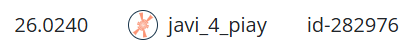

De esta forma se ha conseguido un muy buen resultado pero sin llegar a la puntuación obtenid con KNN. Si se analizan los resultados, se observa que un peor MAE en validación ha dado mejores resultados, esto puede indicar la presencia de overfitting en el modelo básico y puede que también se mantenga pero reducida en el optimizado. Para tratar de penalizar el overfitting se van a introducir 3 parámetros más:

* `gamma`:	Reducción mínima de pérdida requerida para dividir un nodo. Ayuda a controlar la complejidad del modelo.

* `reg_alpha`:	Regularización L1 (tipo Lasso). Añade penalización por complejidad, favoreciendo modelos más simples. Controla la suma de los valores absolutos de los pesos

* `reg_lambda`: Regularización L2 (tipo Ridge). También penaliza la complejidad, pero de forma diferente. Controla la suma de los cuadrados de los pesos.



### XGBoost-Op2

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Modelo base
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

# Espacio de hiperparámetros extendido
param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.25),
    'max_depth': randint(3, 14),
    'min_child_weight': randint(1, 14),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': uniform(0, 2),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

# Búsqueda aleatoria
random_search_xgb = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=75,  # podés subirlo si tenés tiempo y recursos
    scoring='neg_mean_absolute_error',
    cv=6,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Entrenar
random_search_xgb.fit(X_train, y_train)

# Mejor modelo
best_xgb = random_search_xgb.best_estimator_
y_val_pred_xgb = best_xgb.predict(X_valid)
mae_xgb = mean_absolute_error(y_valid, y_val_pred_xgb)

print(f"Mejor MAE en validación (XGB optimizado): {mae_xgb:.4f}")
print("Mejores hiperparámetros (XGB):", random_search_xgb.best_params_)


Fitting 6 folds for each of 75 candidates, totalling 450 fits
Mejor MAE en validación (XGB optimizado): 11.4796
Mejores hiperparámetros (XGB): {'colsample_bytree': np.float64(0.6709398333582008), 'gamma': np.float64(0.18359813162688376), 'learning_rate': np.float64(0.03353924706714003), 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 253, 'reg_alpha': np.float64(0.017161101831750236), 'reg_lambda': np.float64(0.7633644230039109), 'subsample': np.float64(0.9034564885253897)}


In [ ]:
y_test_pred_xgb = best_xgb.predict(test)

# Postprocesado
y_test_pred_xgb = np.rint(y_test_pred_xgb).astype(int)
y_test_pred_xgb[y_test_pred_xgb < 0] = 0

In [ ]:
download_predictions(test_original, y_test_pred_xgb)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250422113108.csv


Los resultados parecen evidenciar nuestra hipótesis de overfitting, ya que al introducir estos nuevos parámetros los resultados han mejorado considerablemente estableciéndose a una centésima del mejor resultado, logrando un 25.79333.

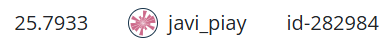

### XGBoost - Optuna

Como se explicó en el caso de Gradient Boosting, para llevar un paso más allá la optimización `GridSearch`no es un buen aliado cuando hay valores continuos, por lo que la optimización se lleva a cabo mediante `Optuna`.

Para la optimización con Optuna se presentan dos métricas MAE: la primera (`study.best_value`) corresponde al MAE promedio obtenido durante el proceso de validación cruzada interna (CV) que realiza Optuna mientras explora distintas combinaciones de hiperparámetros. Esta métrica sirve para guiar la búsqueda del mejor conjunto de parámetros, pero no es directamente comparable con otros MAE obtenidos sobre un conjunto de validación externo.

Por otro lado, el segundo MAE (`mae_optuna`) se calcula aplicando el mejor modelo encontrado por Optuna al conjunto de validación separado (`X_valid`). **Este es el valor que debe compararse con los resultados obtenidos** con otros métodos como RandomizedSearchCV, ya que evalúa el rendimiento real del modelo final sobre datos no vistos durante el entrenamiento.

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
import numpy as np

def objective(trial):
    # Definir los hiperparámetros a optimizar
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 237, 260),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.05, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 4, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 2),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': 42,
        'objective': 'reg:squarederror'
    }

    # Modelo
    model = XGBRegressor(**params)

    # Validación cruzada
    scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=6,
        n_jobs=-1
    )

    return -scores.mean()  # Minimizar el MAE

# Estudio de Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=1000, show_progress_bar=True)

# Resultados
print(f"Mejor MAE validación (Optuna): {study.best_value:.4f}")
print("Mejores hiperparámetros (Optuna):")
print(study.best_params)

# Entrenar modelo final con los mejores parámetros
best_xgb_optuna = XGBRegressor(**study.best_params)
best_xgb_optuna.fit(X_train, y_train)

# Evaluación en el set de validación
y_val_optuna = best_xgb_optuna.predict(X_valid)
mae_optuna = mean_absolute_error(y_valid, y_val_optuna)
print(f"MAE final en validación (modelo Optuna): {mae_optuna:.4f}")

[I 2025-04-23 11:40:46,910] A new study created in memory with name: no-name-2d09a973-685b-413b-8294-1a42cd37f4f6


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2025-04-23 11:40:55,167] Trial 0 finished with value: 13.161532560984293 and parameters: {'n_estimators': 250, 'max_depth': 9, 'learning_rate': 0.03942985583740936, 'min_child_weight': 4, 'subsample': 0.7375921320031614, 'colsample_bytree': 0.5, 'gamma': 0.9923726646154327, 'reg_alpha': 0.23007916317741384, 'reg_lambda': 0.9994434563336947}. Best is trial 0 with value: 13.161532560984293.
[I 2025-04-23 11:41:00,565] Trial 1 finished with value: 13.164869944254557 and parameters: {'n_estimators': 257, 'max_depth': 8, 'learning_rate': 0.054601519655125476, 'min_child_weight': 6, 'subsample': 0.9113290535368639, 'colsample_bytree': 0.5, 'gamma': 1.8912572639425842, 'reg_alpha': 0.3066434715533827, 'reg_lambda': 0.931558475814935}. Best is trial 0 with value: 13.161532560984293.
[I 2025-04-23 11:41:02,309] Trial 2 finished with value: 12.79186487197876 and parameters: {'n_estimators': 244, 'max_depth': 5, 'learning_rate': 0.032701787502142254, 'min_child_weight': 6, 'subsample': 0.72055

Mejor MAE validación (Optuna): 12.1370
Mejores hiperparámetros (Optuna):
{'n_estimators': 243, 'max_depth': 6, 'learning_rate': 0.02819189663439469, 'min_child_weight': 5, 'subsample': 0.9657162756225185, 'colsample_bytree': 0.5, 'gamma': 0.037381343742230025, 'reg_alpha': 0.4605718164238943, 'reg_lambda': 0.7261342935448414}
MAE final en validación (modelo Optuna): 11.0884

In [ ]:
y_test_pred_optuna = best_xgb_optuna.predict(test)

# Postprocesado
y_test_pred_optuna = np.rint(y_test_pred_optuna).astype(int)
y_test_pred_optuna[y_test_pred_optuna < 0] = 0

# Guardar las predicciones
download_predictions(test_original, y_test_pred_optuna)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250423124433.csv


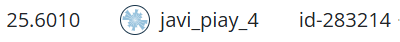

Gracias a la optimización con `Optuna`se ha logrado mejorar el buen registro obtenido con KNN y establecer el record en 25.6010. El próximo objetivo es reducir este valor por debajo de los 25.6

### XGBoost-Optuna2

Se intenta acotar un poco más el espacio de búsqueda

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
import numpy as np

def objective(trial):
    # Definir los hiperparámetros a optimizar
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 238, 245),          # Muy centrado en los mejores
        'max_depth': trial.suggest_int('max_depth', 5, 6),                    # Los mejores son 5 o 6
        'learning_rate': trial.suggest_float('learning_rate', 0.024, 0.046),  # Amplía ligeramente el mejor
        'min_child_weight': trial.suggest_int('min_child_weight', 4, 5),      # Consistentes en 4 o 5
        'subsample': trial.suggest_float('subsample', 0.95, 0.99),            # Cerca del 0.95-0.98
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.65), # Mejores en 0.5-0.65
        'gamma': trial.suggest_float('gamma', 0.03, 0.20),                    # Desde muy bajo hasta 0.19
        'reg_alpha': trial.suggest_float('reg_alpha', 0.38, 0.46),            # Mejor zona de regularización L1
        'reg_lambda': trial.suggest_float('reg_lambda', 0.6, 0.98),           # Muy útiles entre 0.6 y 0.98
        'random_state': 24,
        'objective': 'reg:squarederror'
    }

    # Modelo
    model = XGBRegressor(**params)

    # Validación cruzada
    scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_mean_absolute_error',
        cv=8,
        n_jobs=-1
    )

    return -scores.mean()  # Minimizar el MAE

# Estudio de Optuna
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=250, show_progress_bar=True)

# Resultados
print(f"Mejor MAE validación (Optuna): {study.best_value:.4f}")
print("Mejores hiperparámetros (Optuna):")
print(study.best_params)

# Entrenar modelo final con los mejores parámetros
best_xgb_optuna = XGBRegressor(**study.best_params)
best_xgb_optuna.fit(X_train, y_train)

# Evaluación en el set de validación
y_val_optuna = best_xgb_optuna.predict(X_valid)
mae_optuna = mean_absolute_error(y_valid, y_val_optuna)
print(f"MAE final en validación (modelo Optuna): {mae_optuna:.4f}")


[I 2025-04-25 11:00:29,985] A new study created in memory with name: no-name-4c930a2e-1c61-49e5-a05d-62e4847e67c1


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2025-04-25 11:00:37,715] Trial 0 finished with value: 12.573659539222717 and parameters: {'n_estimators': 245, 'max_depth': 6, 'learning_rate': 0.042024817645494886, 'min_child_weight': 5, 'subsample': 0.9633274277894808, 'colsample_bytree': 0.5474006270130399, 'gamma': 0.13094935336860702, 'reg_alpha': 0.43071809167283454, 'reg_lambda': 0.8269110418661463}. Best is trial 0 with value: 12.573659539222717.
[I 2025-04-25 11:00:40,463] Trial 1 finished with value: 12.75870406627655 and parameters: {'n_estimators': 241, 'max_depth': 5, 'learning_rate': 0.03235316094737529, 'min_child_weight': 4, 'subsample': 0.9740009276583633, 'colsample_bytree': 0.5771376941430928, 'gamma': 0.18279436522463938, 'reg_alpha': 0.385075830360173, 'reg_lambda': 0.8958297820738068}. Best is trial 0 with value: 12.573659539222717.
[I 2025-04-25 11:00:43,306] Trial 2 finished with value: 12.81034243106842 and parameters: {'n_estimators': 243, 'max_depth': 5, 'learning_rate': 0.037067006061768736, 'min_child_w

In [ ]:
y_test_pred_optuna = best_xgb_optuna.predict(test)

# Postprocesado
y_test_pred_optuna = np.rint(y_test_pred_optuna).astype(int)
y_test_pred_optuna[y_test_pred_optuna < 0] = 0

# Guardar las predicciones
download_predictions(test_original, y_test_pred_optuna)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250425112046.csv


Se han realizado varios intentos, pero no se ha conseguido mejorar la puntuación anterior a pesar de que el siguiente modelo se ha quedado muy cerca con un MAE real de 25.6058:

Mejor MAE validación (Optuna): 12.3667

Mejores hiperparámetros (Optuna):
{'n_estimators': 240, 'max_depth': 5, 'learning_rate': 0.04582731227381632, 'min_child_weight': 4, 'subsample': 0.9526122418597416, 'colsample_bytree': 0.5, 'gamma': 0.19213479976559916, 'reg_alpha': 0.3821485338692457, 'reg_lambda': 0.9810134305408168}

MAE final en validación (modelo Optuna): 11.4057

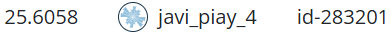

###XGBoost-GroupKFold

En problemas donde existen grupos naturales dentro de los datos (como por ejemplo distintas ciudades en este caso), el uso de GroupKFold puede ser una estrategia adecuada para validar los modelos sin que haya fugas de información entre los subconjuntos de entrenamiento y validación. A diferencia del K-Fold tradicional, que divide las observaciones de forma aleatoria, GroupKFold garantiza que todas las muestras de un mismo grupo estén contenidas exclusivamente en una sola partición (fold). Esto permite evaluar el rendimiento del modelo en grupos que no ha visto durante el entrenamiento, simulando mejor su comportamiento en situaciones del mundo real y reduciendo el riesgo de sobreajuste a patrones específicos de un grupo. Por tanto, puede que en este caso ayude a mejorar la generalización del modelo.

In [ ]:
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import optuna
import numpy as np

# Datos
X = train_combined.drop(['total_cases', 'city', 'city_bin'], axis=1)
y = train_combined['total_cases']
groups = train_combined['city_bin']

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 230, 260),
        'learning_rate': trial.suggest_float('learning_rate', 0.15, 0.55, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'gamma': trial.suggest_float('gamma', 0, 3)
    }

    cv = GroupKFold(n_splits=2)
    maes = []

    for train_idx, val_idx in cv.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBRegressor(random_state=42, **params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        maes.append(mean_absolute_error(y_val, y_pred))

    return np.mean(maes)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=2000, show_progress_bar=True)

print(f"Mejor MAE en GroupKFold: {study.best_value:.4f}")
print("Mejores hiperparámetros:")
print(study.best_params)


[I 2025-04-24 19:31:46,256] A new study created in memory with name: no-name-67f567a3-27e6-426d-8d8c-9741259e43f7


  0%|          | 0/2000 [00:00<?, ?it/s]

[I 2025-04-24 19:31:46,787] Trial 0 finished with value: 40.143174171447754 and parameters: {'n_estimators': 241, 'learning_rate': 0.16020663235448354, 'max_depth': 5, 'min_child_weight': 9, 'subsample': 0.5032181747131702, 'colsample_bytree': 0.45296932262842243, 'reg_alpha': 0.7381537687502155, 'reg_lambda': 0.5897667763047933, 'gamma': 1.786627438255981}. Best is trial 0 with value: 40.143174171447754.
[I 2025-04-24 19:31:47,449] Trial 1 finished with value: 34.28558921813965 and parameters: {'n_estimators': 255, 'learning_rate': 0.17414879351904886, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.9867288184705731, 'colsample_bytree': 0.8887703357303309, 'reg_alpha': 1.7439928106177893, 'reg_lambda': 1.2935929283989978, 'gamma': 2.5913499194844913}. Best is trial 1 with value: 34.28558921813965.
[I 2025-04-24 19:31:48,033] Trial 2 finished with value: 49.28483200073242 and parameters: {'n_estimators': 233, 'learning_rate': 0.3686384895442011, 'max_depth': 10, 'min_child_weight

In [ ]:
# Entrenar modelo con mejores parámetros en todo el train_combined
best_model = XGBRegressor(random_state=42, **study.best_params)
best_model.fit(X, y)

# Predicción sobre test set
X_test = test.drop(['city_bin'], axis=1)
y_test_pred = best_model.predict(X_test)

# Postprocesado
y_test_pred = np.rint(y_test_pred).astype(int)
y_test_pred[y_test_pred < 0] = 0

download_predictions(test_original, y_test_pred)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250424200337.csv


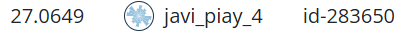

### Dataset separado XGBoost

Con el objetivo de seguir mejorando el modelo, se divide el dataset por cuidades y se va a aplicar el algoritmo que mejor ha funcionado a cada uno de estos por separado.

In [ ]:
# Volver a separar el dataset preprocesado según la ciudad
train_sj_final = train_combined[train_combined['city_bin'] == 1].copy()
train_iq_final = train_combined[train_combined['city_bin'] == 0].copy()

# Lo mismo para el conjunto de test
test_sj = test[test['city_bin'] == 1].copy()
test_iq = test[test['city_bin'] == 0].copy()


In [ ]:
# Eliminamos la columna 'city_bin' (ya no se necesita como feature)
train_sj_final = train_sj_final.drop(['city_bin', 'city'], axis=1, errors='ignore')
train_iq_final = train_iq_final.drop(['city_bin', 'city'], axis=1, errors='ignore')
test_sj = test_sj.drop(['city_bin', 'city'], axis=1, errors='ignore')
test_iq = test_iq.drop(['city_bin', 'city'], axis=1, errors='ignore')


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np

# --- SAN JUAN ---
X_sj = train_sj_final.drop('total_cases', axis=1)
y_sj = train_sj_final['total_cases']
X_train_sj, X_val_sj, y_train_sj, y_val_sj = train_test_split(X_sj, y_sj, test_size=0.2, random_state=42)

xgb_sj = XGBRegressor(random_state=42, verbosity=0)
xgb_sj.fit(X_train_sj, y_train_sj)

y_pred_sj = xgb_sj.predict(X_val_sj)
mae_sj = mean_absolute_error(y_val_sj, y_pred_sj)
print(f"MAE en San Juan: {mae_sj:.4f}")

# --- IQUITOS ---
X_iq = train_iq_final.drop('total_cases', axis=1)
y_iq = train_iq_final['total_cases']
X_train_iq, X_val_iq, y_train_iq, y_val_iq = train_test_split(X_iq, y_iq, test_size=0.2, random_state=42)

xgb_iq = XGBRegressor(random_state=42, verbosity=0)
xgb_iq.fit(X_train_iq, y_train_iq)

y_pred_iq = xgb_iq.predict(X_val_iq)
mae_iq = mean_absolute_error(y_val_iq, y_pred_iq)
print(f"MAE en Iquitos: {mae_iq:.4f}")


MAE en San Juan: 14.5718
MAE en Iquitos: 5.3935


In [ ]:
# Predecir en test
y_test_pred_sj = xgb_sj.predict(test_sj)
y_test_pred_iq = xgb_iq.predict(test_iq)

# Postprocesado
y_test_pred_sj = np.rint(y_test_pred_sj).astype(int)
y_test_pred_sj[y_test_pred_sj < 0] = 0

y_test_pred_iq = np.rint(y_test_pred_iq).astype(int)
y_test_pred_iq[y_test_pred_iq < 0] = 0


Para poder crear un .csv con la estructura adecuada para subir a la plataforma es necesario unir los dos datasets de nuevo.

In [ ]:
# Unir las predicciones en el mismo orden que en test_original
y_test_pred_unido = np.concatenate([y_test_pred_sj, y_test_pred_iq])

# Descargar en formato DrivenData
download_predictions(test_original, y_test_pred_unido)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250422174507.csv


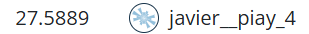

No es realmente un mal resultado para el modelo básico, veamos si optimizando los parámetros con `RandomizedSearch` mejora considerablmente.

### Dataset separado-XGBoost-Op

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# --- SAN JUAN ---
X_sj = train_sj_final.drop('total_cases', axis=1)
y_sj = train_sj_final['total_cases']
X_train_sj, X_val_sj, y_train_sj, y_val_sj = train_test_split(X_sj, y_sj, test_size=0.2, random_state=42)

# Parámetros para la búsqueda aleatoria (con penalización por overfitting)
param_dist_sj = {
    'max_depth': randint(3, 15),                  # Controla la profundidad del árbol
    'learning_rate': uniform(0.01, 0.3),          # Tasa de aprendizaje
    'n_estimators': randint(10, 50),           # Número de árboles
    'subsample': uniform(0.5, 0.5),                # Submuestra de los datos
    'colsample_bytree': uniform(0.5, 0.5),        # Submuestra de características
    'min_child_weight': randint(1, 20),            # Penaliza los árboles con hojas muy pequeñas
    'reg_alpha': uniform(0, 1),                    # Regularización L1
    'reg_lambda': uniform(0, 1),                   # Regularización L2
    'gamma': uniform(0, 2)                         # Penaliza las particiones en los árboles
}

# Modelo base
xgb_sj = XGBRegressor(random_state=42, verbosity=0)

# RandomizedSearchCV
random_search_sj = RandomizedSearchCV(
    estimator=xgb_sj,
    param_distributions=param_dist_sj,
    n_iter=100,              # Número de combinaciones a probar
    scoring='neg_mean_absolute_error',  # Optimiza el MAE
    cv=6,                     # Cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1                 # Usa todos los núcleos disponibles
)

# Ajustar al conjunto de entrenamiento de San Juan
random_search_sj.fit(X_train_sj, y_train_sj)

# Mejor modelo
best_xgb_sj = random_search_sj.best_estimator_

# Predicción y evaluación
y_pred_sj_optimized = best_xgb_sj.predict(X_val_sj)
mae_sj_optimized = mean_absolute_error(y_val_sj, y_pred_sj_optimized)
print(f"MAE optimizado en San Juan: {mae_sj_optimized:.4f}")



# --- IQUITOS ---
X_iq = train_iq_final.drop('total_cases', axis=1)
y_iq = train_iq_final['total_cases']
X_train_iq, X_val_iq, y_train_iq, y_val_iq = train_test_split(X_iq, y_iq, test_size=0.2, random_state=42)

# Parámetros para la búsqueda aleatoria (con penalización por overfitting)
param_dist_iq = {
    'max_depth': randint(3, 15),                  # Controla la profundidad del árbol
    'learning_rate': uniform(0.01, 0.3),          # Tasa de aprendizaje
    'n_estimators': randint(10, 50),           # Número de árboles
    'subsample': uniform(0.5, 0.5),                # Submuestra de los datos
    'colsample_bytree': uniform(0.5, 0.5),        # Submuestra de características
    'min_child_weight': randint(1, 20),            # Penaliza los árboles con hojas muy pequeñas
    'reg_alpha': uniform(0, 1),                    # Regularización L1
    'reg_lambda': uniform(0, 1),                   # Regularización L2
    'gamma': uniform(0, 2)                         # Penaliza las particiones en los árboles
}

# Modelo base
xgb_iq = XGBRegressor(random_state=42, verbosity=0)

# RandomizedSearchCV
random_search_iq = RandomizedSearchCV(
    estimator=xgb_iq,
    param_distributions=param_dist_iq,
    n_iter=100,              # Número de combinaciones a probar
    scoring='neg_mean_absolute_error',  # Optimiza el MAE
    cv=6,                     # Cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1                 # Usa todos los núcleos disponibles
)

# Ajustar al conjunto de entrenamiento de Iquitos
random_search_iq.fit(X_train_iq, y_train_iq)

# Mejor modelo
best_xgb_iq = random_search_iq.best_estimator_

# Predicción y evaluación
y_pred_iq_optimized = best_xgb_iq.predict(X_val_iq)
mae_iq_optimized = mean_absolute_error(y_val_iq, y_pred_iq_optimized)
print(f"MAE optimizado en Iquitos: {mae_iq_optimized:.4f}")


Fitting 6 folds for each of 100 candidates, totalling 600 fits
MAE optimizado en San Juan: 13.6933
Fitting 6 folds for each of 100 candidates, totalling 600 fits
MAE optimizado en Iquitos: 5.1987


In [ ]:
# Ver los mejores parámetros
print(f"Mejores parámetros para San Juan: {random_search_sj.best_params_}")
# Ver los mejores parámetros
print(f"Mejores parámetros para Iquitos: {random_search_iq.best_params_}")

Mejores parámetros para San Juan: {'colsample_bytree': np.float64(0.8182017987230057), 'gamma': np.float64(3.4028478840471994), 'learning_rate': np.float64(0.21315050271489452), 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 42, 'reg_alpha': np.float64(3.433612530208009), 'reg_lambda': np.float64(3.461918427231866), 'subsample': np.float64(0.8129698350507863)}
Mejores parámetros para Iquitos: {'colsample_bytree': np.float64(0.8658238776498202), 'gamma': np.float64(1.3830691882673967), 'learning_rate': np.float64(0.0850049347648314), 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 21, 'reg_alpha': np.float64(2.2869820821250553), 'reg_lambda': np.float64(3.252613203374492), 'subsample': np.float64(0.8772714370423411)}


In [ ]:
# Predicción en el conjunto de test
y_test_pred_sj_optimized = best_xgb_sj.predict(test_sj)
y_test_pred_iq_optimized = best_xgb_iq.predict(test_iq)

# Postprocesado: redondear, convertir a enteros y eliminar negativos
y_test_pred_sj_optimized = np.rint(y_test_pred_sj_optimized).astype(int)
y_test_pred_iq_optimized = np.rint(y_test_pred_iq_optimized).astype(int)

y_test_pred_sj_optimized[y_test_pred_sj_optimized < 0] = 0
y_test_pred_iq_optimized[y_test_pred_iq_optimized < 0] = 0

# Unir las predicciones
y_test_pred_unido = np.concatenate([y_test_pred_sj_optimized, y_test_pred_iq_optimized])

# Descargar las predicciones
download_predictions(test_original, y_test_pred_unido)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250422181029.csv


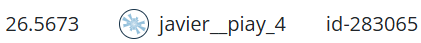

Parece que con un buen ajuste de parámetros el modelo es capaz de mejorar. Se va a comprobar si con `Optuna`se consigue todavía un ajuste más fino sin llegar al sobreaprendizaje.

### Dataset separado-XGBoost-Optuna

#### San Juan

In [ ]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Función objetivo para San Juan
def objective_sj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 40, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.15, 0.25, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'gamma': trial.suggest_float('gamma', 0, 3)
    }

    model = XGBRegressor(random_state=42, **params)
    model.fit(X_train_sj, y_train_sj)
    y_pred = model.predict(X_val_sj)
    return mean_absolute_error(y_val_sj, y_pred)

# Crear un estudio para la optimización en San Juan
study_sj = optuna.create_study(direction='minimize')
study_sj.optimize(objective_sj, n_trials=200, show_progress_bar=True)

# Mejor modelo
print(f"Mejor MAE validación (Optuna San Juan): {study_sj.best_value:.4f}")
print("Mejores hiperparámetros (Optuna San Juan):")
print(study_sj.best_params)

# Entrenar el modelo final con los mejores parámetros
best_xgb_sj_optuna = XGBRegressor(random_state=42, **study_sj.best_params)
best_xgb_sj_optuna.fit(X_train_sj, y_train_sj)

# Predicción final
y_pred_sj_optuna = best_xgb_sj_optuna.predict(X_val_sj)
mae_sj_optuna = mean_absolute_error(y_val_sj, y_pred_sj_optuna)
print(f"MAE final en validación (Optuna San Juan): {mae_sj_optuna:.4f}")

# Predicción sobre el conjunto de test
y_test_pred_sj_optuna = best_xgb_sj_optuna.predict(test_sj)

# Postprocesado: redondear, convertir a enteros y eliminar negativos
y_test_pred_sj_optuna = np.rint(y_test_pred_sj_optuna).astype(int)
y_test_pred_sj_optuna[y_test_pred_sj_optuna < 0] = 0



[I 2025-04-24 20:05:26,123] A new study created in memory with name: no-name-92b570b7-0354-4aac-aa0f-240e9d7f4e1e


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-04-24 20:05:26,263] Trial 0 finished with value: 14.334036827087402 and parameters: {'n_estimators': 61, 'learning_rate': 0.17451167245551047, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.960804448892224, 'colsample_bytree': 0.6438264313415745, 'reg_alpha': 1.3099930253792418, 'reg_lambda': 0.5801534099089654, 'gamma': 1.3335124226593145}. Best is trial 0 with value: 14.334036827087402.
[I 2025-04-24 20:05:26,420] Trial 1 finished with value: 16.48244285583496 and parameters: {'n_estimators': 57, 'learning_rate': 0.23144373430341297, 'max_depth': 6, 'min_child_weight': 6, 'subsample': 0.6839886031148321, 'colsample_bytree': 0.6960992053772346, 'reg_alpha': 0.13680252123709002, 'reg_lambda': 0.17684518066735477, 'gamma': 0.8855012968073336}. Best is trial 0 with value: 14.334036827087402.
[I 2025-04-24 20:05:26,826] Trial 2 finished with value: 14.64233112335205 and parameters: {'n_estimators': 100, 'learning_rate': 0.2097333571015067, 'max_depth': 10, 'min_child_weight

#### Iquitos

In [ ]:
# Función objetivo para Iquitos
def objective_iq(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 15, 60),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 8, 14),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'gamma': trial.suggest_float('gamma', 0, 3)
    }

    model = XGBRegressor(random_state=42, **params)
    model.fit(X_train_iq, y_train_iq)
    y_pred = model.predict(X_val_iq)
    return mean_absolute_error(y_val_iq, y_pred)

# Crear un estudio para la optimización en Iquitos
study_iq = optuna.create_study(direction='minimize')
study_iq.optimize(objective_iq, n_trials=200, show_progress_bar=True)

# Mejor modelo
print(f"Mejor MAE validación (Optuna Iquitos): {study_iq.best_value:.4f}")
print("Mejores hiperparámetros (Optuna Iquitos):")
print(study_iq.best_params)

# Entrenar el modelo final con los mejores parámetros
best_xgb_iq_optuna = XGBRegressor(random_state=42, **study_iq.best_params)
best_xgb_iq_optuna.fit(X_train_iq, y_train_iq)

# Predicción final
y_pred_iq_optuna = best_xgb_iq_optuna.predict(X_val_iq)
mae_iq_optuna = mean_absolute_error(y_val_iq, y_pred_iq_optuna)
print(f"MAE final en validación (Optuna Iquitos): {mae_iq_optuna:.4f}")

# Predicción sobre el conjunto de test
y_test_pred_iq_optuna = best_xgb_iq_optuna.predict(test_iq)

# Postprocesado: redondear, convertir a enteros y eliminar negativos
y_test_pred_iq_optuna = np.rint(y_test_pred_iq_optuna).astype(int)
y_test_pred_iq_optuna[y_test_pred_iq_optuna < 0] = 0


[I 2025-04-24 20:08:02,173] A new study created in memory with name: no-name-d38a7587-a280-4a47-90aa-cef5503378aa


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-04-24 20:08:02,692] Trial 0 finished with value: 7.5658745765686035 and parameters: {'n_estimators': 51, 'learning_rate': 0.26453955139977825, 'max_depth': 14, 'min_child_weight': 5, 'subsample': 0.5916453398090458, 'colsample_bytree': 0.8646514298271704, 'reg_alpha': 0.9302143911481568, 'reg_lambda': 0.35439964854144734, 'gamma': 2.5764585951705863}. Best is trial 0 with value: 7.5658745765686035.
[I 2025-04-24 20:08:03,052] Trial 1 finished with value: 6.05758810043335 and parameters: {'n_estimators': 17, 'learning_rate': 0.019753083889333847, 'max_depth': 9, 'min_child_weight': 1, 'subsample': 0.7238743136892105, 'colsample_bytree': 0.6736765454214104, 'reg_alpha': 1.4897354904083626, 'reg_lambda': 0.3047931190665145, 'gamma': 0.727511170007218}. Best is trial 1 with value: 6.05758810043335.
[I 2025-04-24 20:08:03,794] Trial 2 finished with value: 6.094240665435791 and parameters: {'n_estimators': 18, 'learning_rate': 0.011638748356563498, 'max_depth': 10, 'min_child_weight'

Para

In [ ]:
# Unir las predicciones de San Juan e Iquitos
y_test_pred_unido = np.concatenate([y_test_pred_sj_optuna, y_test_pred_iq_optuna])

# Descargar las predicciones
download_predictions(test_original, y_test_pred_unido)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded practica2_pred_20250424201006.csv


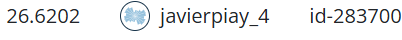

---
# Conclusiones
---

| Modelo | MAE test (DrivenData) | MAE validación | Algoritmo | Hiperparámetros | Descripción |
|--------|------------------------|----------------|-----------|-----------------|-------------|
| XGBoost - Optuna | **25.6010** | 11.0884 | XGBoost Regressor | `n_estimators=243`, `max_depth=6`, `learning_rate=0.0282`, `min_child_weight=5`, `subsample=0.9657`, `colsample_bytree=0.5`, `gamma=0.0374`, `reg_alpha=0.4606`, `reg_lambda=0.7261` | Optimización con Optuna penalizando sobreajuste |
| XGBoost - Optuna2 | 25.6058 | 11.4057 | XGBoost Regressor | `n_estimators=240`, `max_depth=5`, `learning_rate=0.0458`, `min_child_weight=4`, `subsample=0.9526`, `colsample_bytree=0.5`, `gamma=0.1921`, `reg_alpha=0.3821`, `reg_lambda=0.9810` | Otra corrida con Optuna buscando mejora fina |
| XGBoost - Op2 | 25.7933 | 11.4796 | XGBoost Regressor | `colsample_bytree=0.6709`, `gamma=0.1836`, `learning_rate=0.0335`, `max_depth=6`, `min_child_weight=5`, `n_estimators=253`, `reg_alpha=0.0172`, `reg_lambda=0.7634`, `subsample=0.9035` | XGB ajustado con RandomizedSearch y regularización |
| KNN - Grid | 25.7861 | 16.2737 | KNN Regressor | `knn__algorithm='auto'`, `knn__leaf_size=20`, `knn__metric='minkowski'`, `knn__n_neighbors=25`, `knn__p=1`, `knn__weights='distance'` | KNN optimizado mediante GridSearchCV |
| KNN - Op | 25.8173 | 16.3720 | KNN Regressor | `knn__n_neighbors=23`, `knn__p=1`, `knn__weights='distance'` | KNN optimizado mediante RandomizedSearch |
| XGBoost - Op | 26.0240 | 11.8215 | XGBoost Regressor | `colsample_bytree=0.5944`, `learning_rate=0.0658`, `max_depth=5`, `min_child_weight=3`, `n_estimators=197`, `subsample=0.9435` | XGB optimizado con RandomizedSearch |
| Gradient Boosting - Op | 26.1587 | 11.2558 | Gradient Boosting Regressor | `learning_rate=0.0311`, `max_depth=5`, `min_samples_leaf=4`, `min_samples_split=7`, `n_estimators=239`, `subsample=0.7697` | Gradient Boosting con RandomizedSearch |
| Dataset separado XGB - Op | 26.5673 | sj = 13.6933 <br> <br>iq = 5.1987 | XGBoost Regressor | *San Juan:* `colsample_bytree=0.8182`, `gamma=3.4028`, `learning_rate=0.2132`, `max_depth=5`, `min_child_weight=1`, `n_estimators=42`, `reg_alpha=3.4336`, `reg_lambda=3.4619`, `subsample=0.8130`<br> <br> *Iquitos:* `colsample_bytree=0.8658`, `gamma=1.3831`, `learning_rate=0.0850`, `max_depth=10`, `min_child_weight=5`, `n_estimators=21`, `reg_alpha=2.2870`, `reg_lambda=3.2526`, `subsample=0.8773` | Dataset separado y optimización con RandomizedSearch |
| Dataset separado XGB - Optuna | 26.6202 | sj = 12.1530 <br> <br>iq = 4.5423 | XGBoost Regressor | *San Juan:* `n_estimators=100`, `learning_rate=0.2006`, `max_depth=7`, `min_child_weight=2`, `subsample=0.9281`, `colsample_bytree=0.9860`, `reg_alpha=1.5611`, `reg_lambda=1.4657`, `gamma=0.5848`<br> <br>*Iquitos:* `n_estimators=54`, `learning_rate=0.0590`, `max_depth=14`, `min_child_weight=1`, `subsample=0.9151`, `colsample_bytree=0.9501`, `reg_alpha=0.1955`, `reg_lambda=1.9387`, `gamma=2.8602` | Optimización con Optuna por ciudad |
| RandomForest - manual | 26.6923 | 13.9667 | RandomForest Regressor | `criterion='absolute_error'`, `max_depth=15`, `min_samples_leaf=6`, `min_samples_split=17`, `n_estimators=63` | RandomForest ajustado manualmente |
| RandomForest - Op | 26.7043 | 13.9922 | RandomForest Regressor | `bootstrap=True`, `criterion='absolute_error'`, `max_depth=16`, `max_features=1.0`, `min_samples_leaf=6`, `min_samples_split=17`, `n_estimators=64` | RandomForest optimizado |
| RandomForest - básico | 26.8894 | 15.1277 | RandomForest Regressor | - | Modelo base RandomForest |
| XGBoost - básico | 27.0601 | 11.6136 | XGBoost Regressor | - | Modelo base XGB |
| XGBoost - GroupKFold | 27.0649 | 23.3767 | XGBoost Regressor | `n_estimators=254`, `learning_rate=0.4502`, `max_depth=7`, `min_child_weight=9`, `subsample=0.9801`, `colsample_bytree=0.9259`, `reg_alpha=1.9816`, `reg_lambda=1.0104`, `gamma=2.3549` | GroupKFold por ciudad para evitar leakage |
| Gradient Boosting - Optuna | 27.1731 | 10.1810 | Gradient Boosting Regressor | `n_estimators=237`, `learning_rate=0.0646`, `max_depth=6`, `min_samples_split=6`, `min_samples_leaf=4`, `subsample=0.9782` | Gradient Boosting optimizado con Optuna |
| Dataset separado XGB | 27.5889 | sj = 14.5718 <br> <br>iq = 5.3935 | XGBoost Regressor | - | Dataset separado, sin optimización detallada |
| Gradient Boosting - básico | 27.8798 | 14.6336 | Gradient Boosting Regressor | - | Modelo base Gradient Boosting |
| KNN - básico | 27.8798 | 18.3192 | KNN Regressor | - | Modelo base KNN |
| SVR - básico | 29.8870 | 16.2034 | SVR | - | SVR sin ajuste |
| SVR - Op | 31.4279 | 15.5387 | SVR | `C=22.1279`, `degree=3`, `epsilon=0.0092`, `gamma='auto'`, `kernel='rbf'` | SVR optimizado con RandomizedSearch |



**Modelo final elegido**
* Nombre/Identificador: XGBoost - Optuna
* MAE test (DrivenData): 25.6010
* MAE validación: 11.0884
* Algoritmo ML: Extreme Gradient Boosting (XGB) Regressor
* Hiperparámetros:

  * `n_estimators=243`, `max_depth=6`, `learning_rate=0.0282`, `min_child_weight=5`, `subsample=0.9657`, `colsample_bytree=0.5`, `gamma=0.0374`, `reg_alpha=0.4606`, `reg_lambda=0.7261`

* Lista de características:

|                        | Lista Variables                      |                      |
|----------------------------------|----------------------------------|----------------------------------|
| year                             | ndvi_ne                          | ndvi_nw                          |
| ndvi_se                          | ndvi_sw                          | precipitation_amt_mm            |
| reanalysis_air_temp_k            | reanalysis_avg_temp_k            | reanalysis_dew_point_temp_k     |
| reanalysis_max_air_temp_k        | reanalysis_min_air_temp_k        | reanalysis_precip_amt_kg_per_m2 |
| reanalysis_relative_humidity_percent | reanalysis_tdtr_k           | station_avg_temp_c              |
| station_diur_temp_rng_c          | station_max_temp_c               | station_min_temp_c              |
| station_precip_mm                |  city_bin                    | month_sin                        |
| month_cos                        | week_sin                         | week_cos                         |



* Las transformaciones aplicadas son las siguientes:
  * Eliminación de filas con excesivos valores nulos (+ de 4).
  * Imputación de los valores faltantes restantes mediante `IterativeImputer`.
  * Detección y eliminación de valores atípicos extremos utilizando el criterio de 3 * IQR.
  * Transformación de la variable categórica `city` a una versión binarizada (`city_bin`),
  * Transformaciones temporales (month_sin, month_cos, week_sin  week_cos, etc.) para capturar estacionalidades.
  * Eliminación por redundancia de las variables `reanalysis_sat_precip_amt_mm` y `reanalysis_specific_humidity_g_per_kg`, `month`, `weekofyear` y `week_start_date`.

El proceso de modelado comenzó con la evaluación de distintos algoritmos básicos como Random Forest, Gradient Boosting, KNN, SVR y XGBoost, sin ajustes de hiperparámetros. Esta fase inicial sirvió como línea base comparativa. A pesar de que XGBoost y Gradient Boosting obtuvieron buenos MAEs de validación (alrededor de 11.6 y 14.6 respectivamente), sus puntuaciones en el MAE real (test DrivenData) se situaban en torno a 27–28, lo que los hacía insuficientes para considerarse soluciones competitivas. SVR y KNN mostraron un rendimiento inferior inicialmente, aunque KNN sorprendió posteriormente con una mejora considerable tras optimización.

Tras esta fase exploratoria, se procedió a optimizar modelos más prometedores. En KNN, se aplicaron tanto GridSearchCV como RandomizedSearchCV, logrando resultados muy competitivos: 25.7861 y 25.8173 de MAE en test respectivamente. Si bien estos valores no fueron los más bajos, sí mostraron que un modelo sencillo, bien ajustado y con un buen preprocesado puede obtener rendimientos más que aceptables, lo que justifica su inclusión entre los modelos destacados.

En paralelo, se optimizó Random Forest mediante ajustes manuales y búsqueda aleatoria. Sin embargo, los resultados apenas mejoraron el modelo base, quedando todos los modelos optimizados alrededor de un MAE real de 26.69, lo que indicaba ciertas limitaciones del algoritmo frente a la complejidad del problema. En cambio, Gradient Boosting, tras optimización con RandomizedSearchCV y Optuna, alcanzó buenos MAE de validación (~10.2), pero su rendimiento en el test real permaneció en torno a 26.15–27.17, lo que sugiere cierto sobreajuste al conjunto de validación.

Dado el buen desempeño de XGBoost una vez optimizado mediante RandomizedSearchCV, se centró la atención en este algoritmo. Las optimizaciones con Optuna tanto sobre el conjunto total como en datasets separados por ciudad, permitieron afinar al máximo su rendimiento. Entrenar modelos específicos por ciudad (San Juan e Iquitos) fue una estrategia prometedora a nivel de validación, pero no logró mejorar el MAE global en el test, situándose siempre por encima de 26.5. También se probó el uso de GroupKFold para evitar posibles fugas de datos entre ciudades, pero no logró mejorar los resultados globales.

Finalmente, el modelo que ofreció el mejor compromiso entre validación y generalización fue el XGBoost optimizado con Optuna sobre el dataset completo, alcanzando un MAE real de 25.6010 y una validación muy ajustada (11.0884), convirtiéndose en el modelo final seleccionado. Incluso otro modelo alternativo optimizado de la misma forma con Optuna, pero con ligeras variaciones alcanzó 25.6058, mostrando consistencia y robustez. De esta forma, a pesar de los buenos resultados obtenidos por KNN, XGBoost destacó por su estabilidad y capacidad para manejar relaciones complejas no lineales, lo que lo posiciona como la opción más sólida para este problema.


Aunque el trabajo realizado ha sido exhaustivo dentro del tiempo disponible, existen varias líneas de mejora que no se han abordado por limitaciones temporales, pero que podrían enriquecer notablemente la calidad del modelo final. Una de ellas sería tratar los datos de forma más personalizada, especialmente en lo relativo al preprocesamiento diferenciado por ciudad, ajustando la limpieza, normalización e imputación a las características particulares de San Juan e Iquitos. Asimismo, habría sido interesante explorar un mayor número de modelos específicamente entrenados para cada ciudad, ya que los resultados previos mostraron que los patrones epidémicos difieren considerablemente. Además, no se ha realizado un proceso sistemático de selección de características, lo que podría haber permitido reducir la dimensionalidad del problema, eliminar ruido y mejorar la capacidad de generalización de los modelos.

Estas mejoras, aunque no se han podido implementar en esta entrega, supondrían pasos lógicos y prometedores para continuar optimizando el enfoque predictivo en futuros desarrollos.